# Figure2(Stackedbar) for bertopic

In [1]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.date_setting import Date_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
import lib.visualization.font_setting as font_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic, 
                                                      sort_distribution_by_list)
mpl.rcParams['font.family'] = font_setting.init_font()

Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
plotgen = PlotGen()

In [ ]:
def draw_bar_plot_for_bertopic(idx_num, proportion_dict, list_10, option_dict, output_dir):
    fig, axs = mpl.pyplot.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
    color_list = Color_Setting.color_list
    alpha_list = [1, 1, 0.7]
    panel_labels = ['A.', 'B.', 'C.', 'D.']

    ### stacked topic plots
    for i, (title, proportion) in enumerate(proportion_dict.items()):
        plotgen.draw_topic_stack(
            axs[i],
            title,
            proportion,
            list_10[title],
            color_list[i],
            alpha_list[i],
            panel_labels[i]
        )


    fig.supxlabel("Week relative to ChatGPT release", fontsize=22)
    fig.supylabel('Accumulated topic share', fontsize=22)

    filename = f"{idx_num}_bar_plot_{option_dict['selected_tags']}_{option_dict['model']}_{option_dict['year_range']}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close()

In [ ]:
def draw_scatter_line_plot_for_bertopic(idx_num, proportion_dict, option_dict, output_dir):
    fig, axs = mpl.pyplot.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
    color_list = Color_Setting.color_list
    alpha_list = [1, 1, 0.7]
    panel_labels = ['A.', 'B.', 'C.', 'D.']

    ### stacked topic plots
    for i, (title, proportion) in enumerate(proportion_dict.items()):
        x = list(sorted(proportion['rel_week'].unique()))
        y = list(proportion.groupby('rel_week')['proportion'].sum())


        plotgen.draw_topic_regression(
            axs[i],
            title,
            x,
            y, 
            color_list[i],
            alpha_list[i],
            panel_labels[i]
        )


    fig.supxlabel("Week relative to ChatGPT release", fontsize=22)
    fig.supylabel('Accumulated topic share', fontsize=22)
    filename = f"{idx_num}_scatter_plot_{option_dict['selected_tags']}_{option_dict['model']}_{option_dict['year_range']}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close()

[Start....] drawing figures for python language


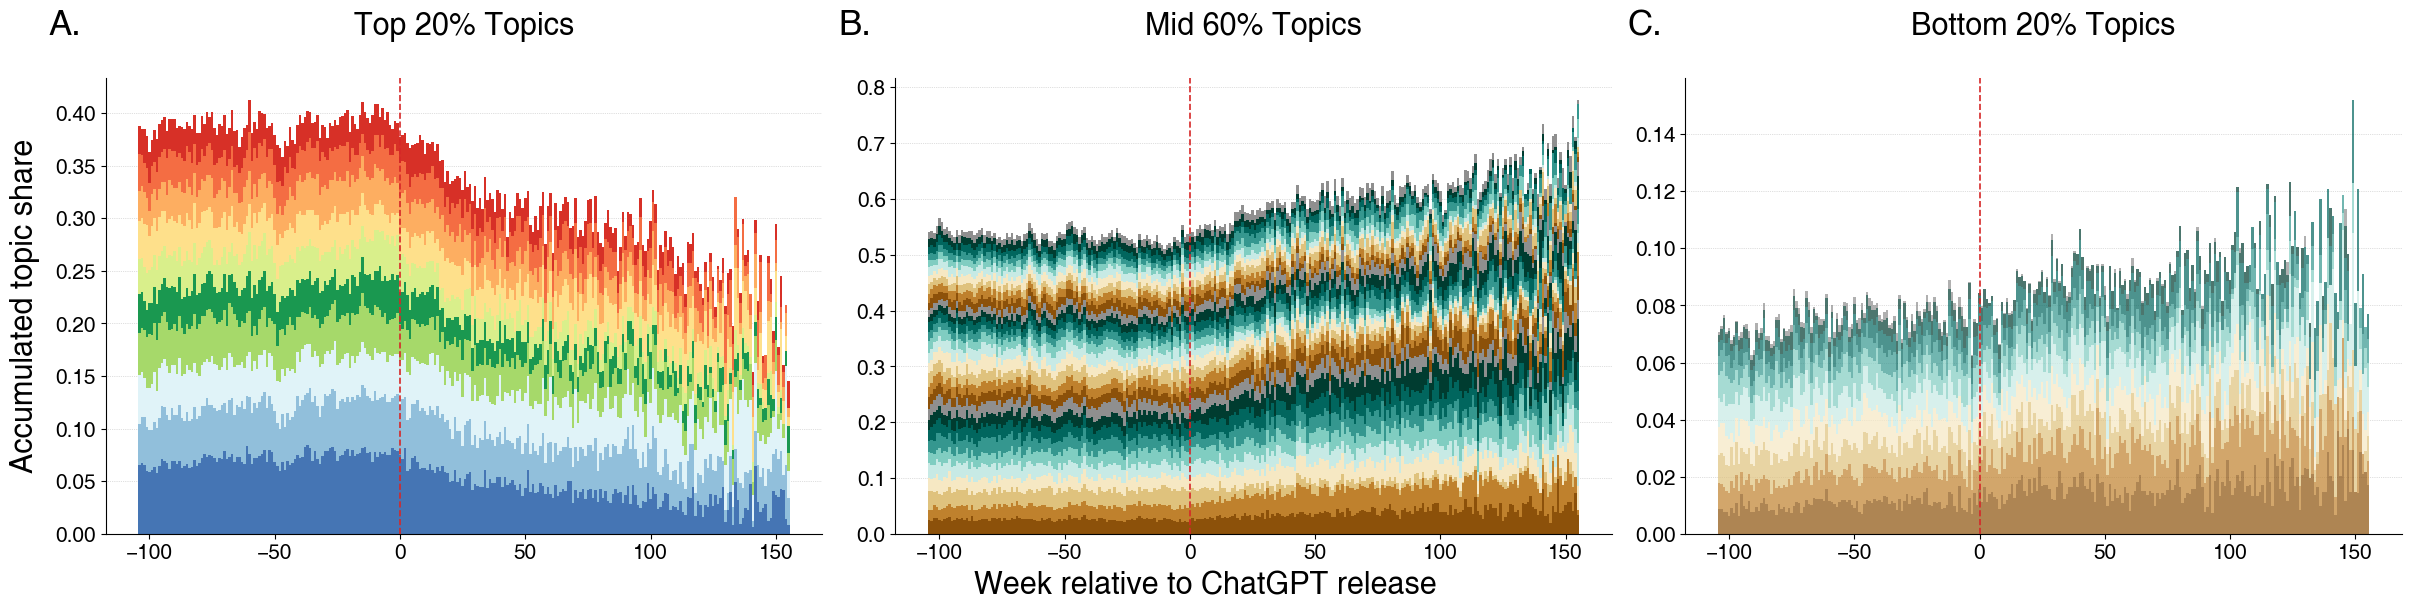

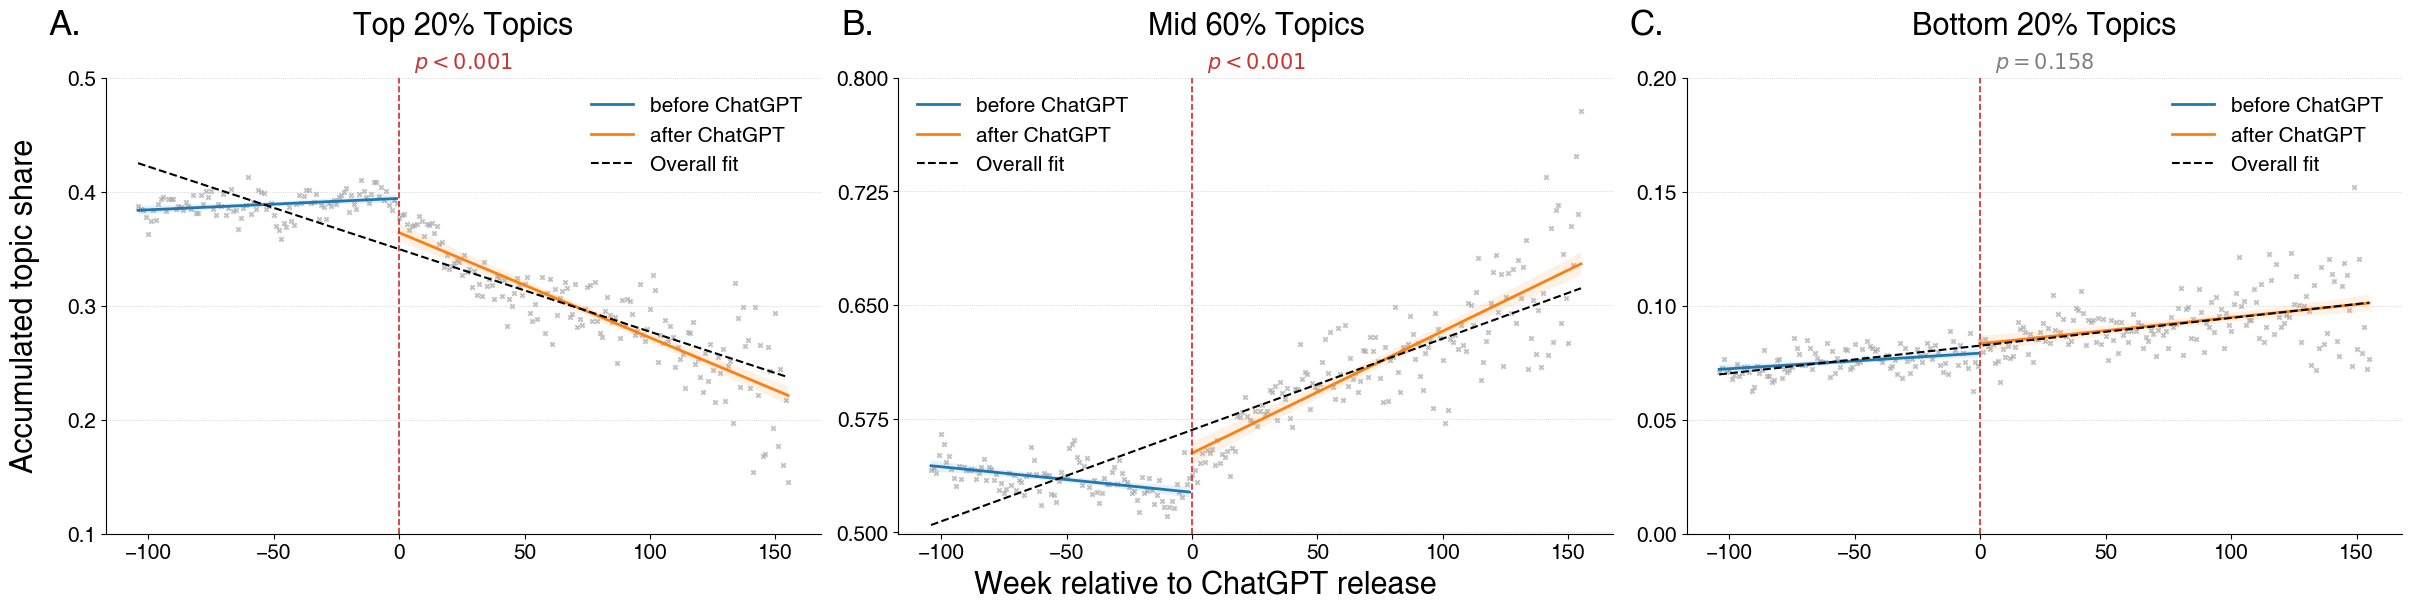

[Start....] drawing figures for javascript language


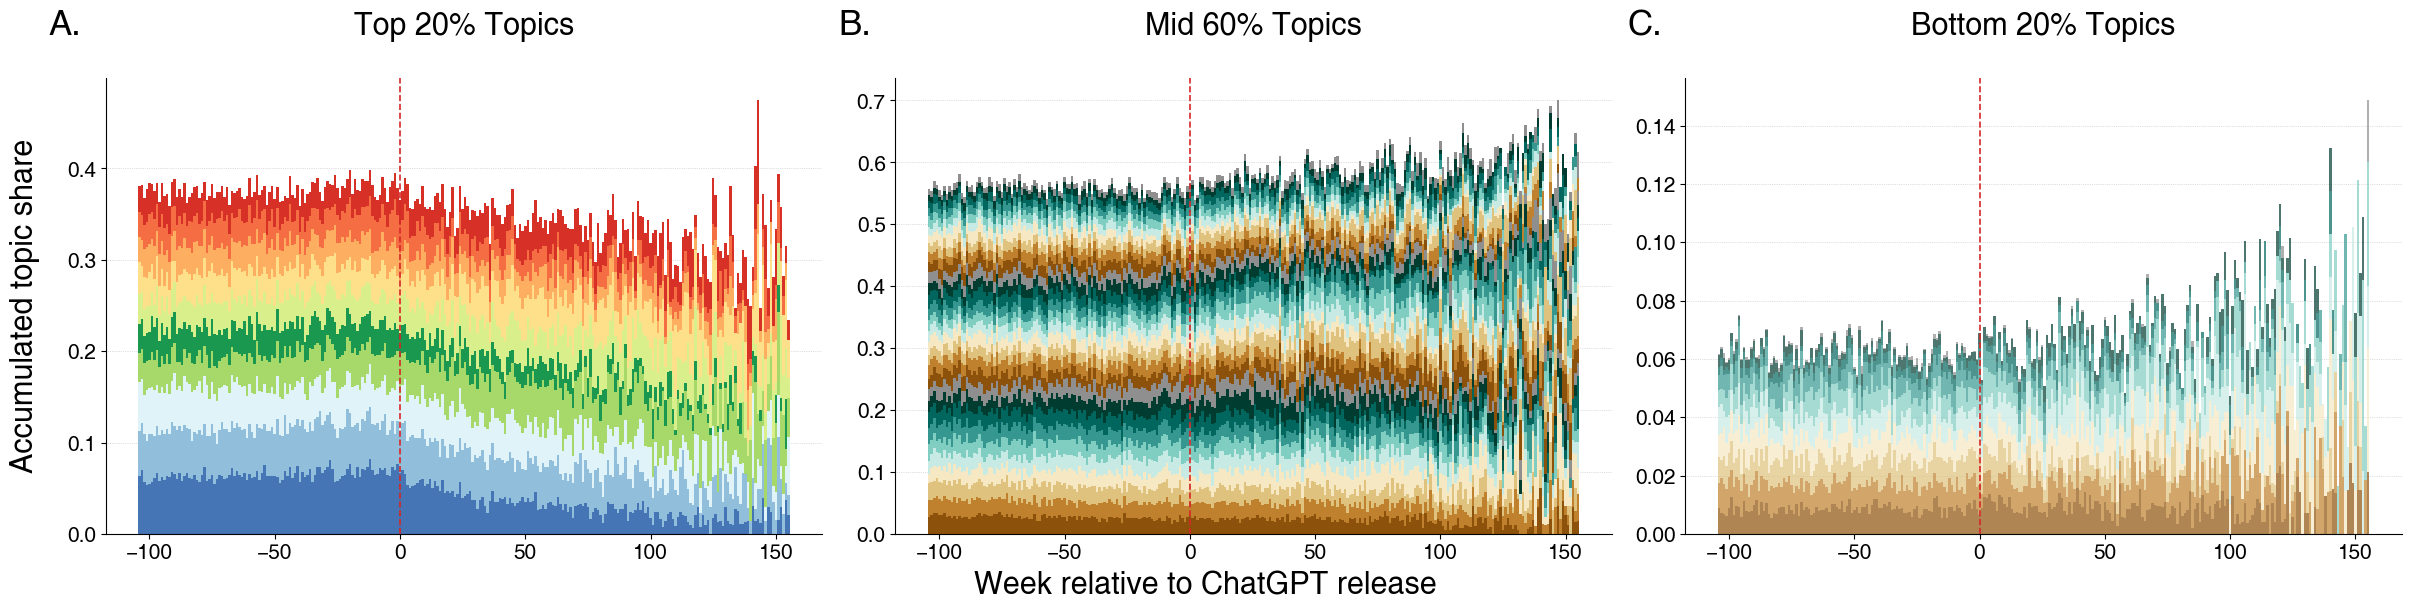

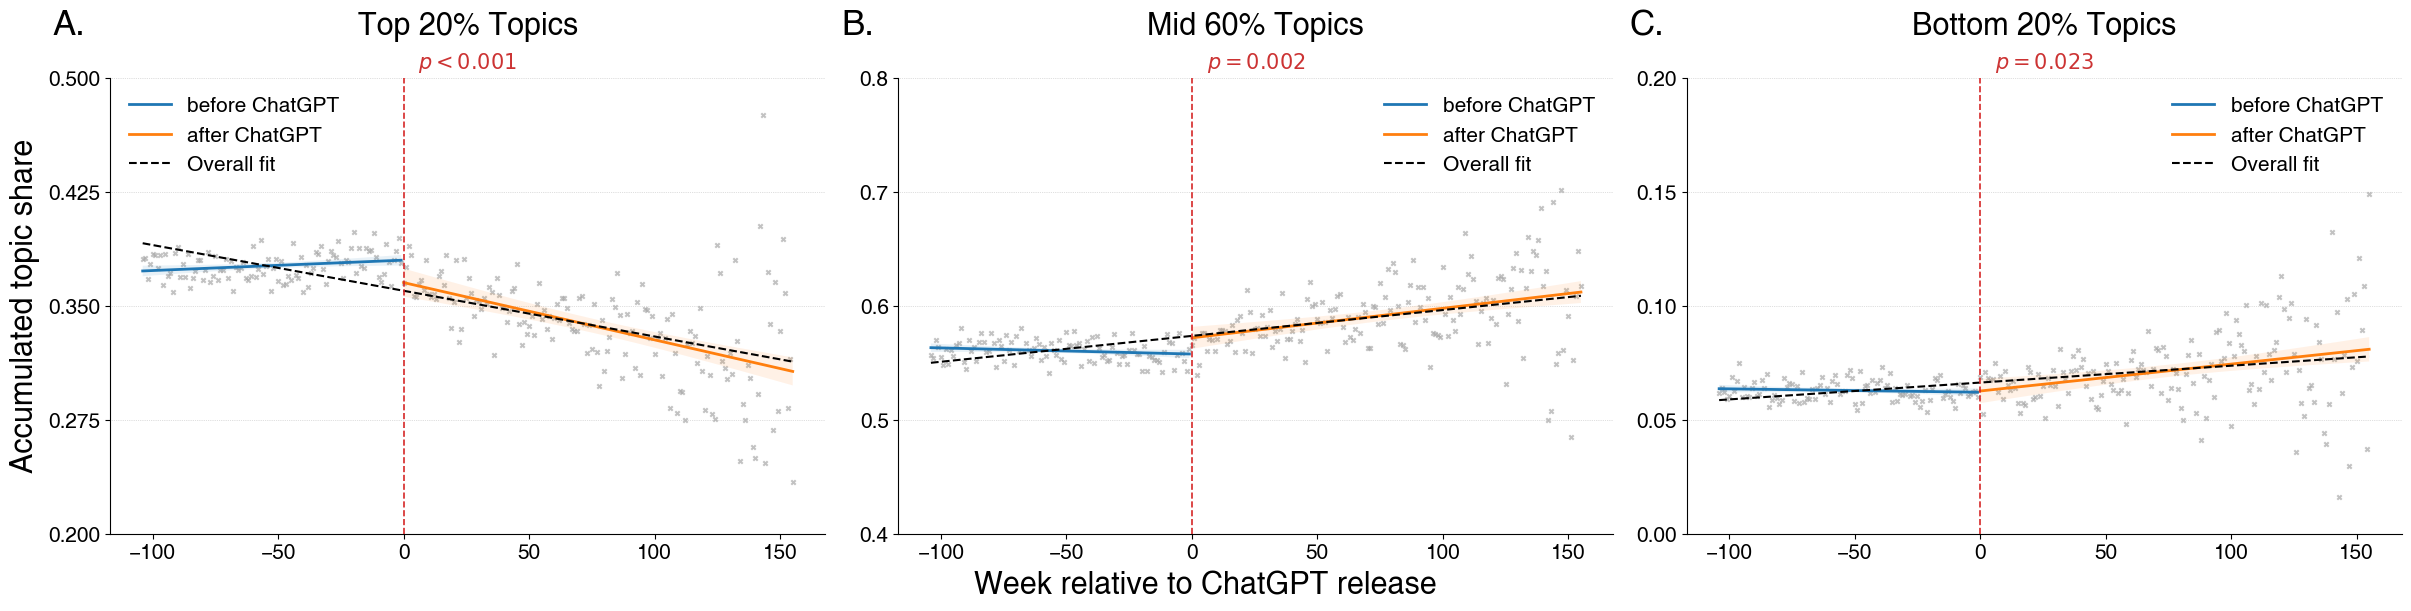

[Start....] drawing figures for java language


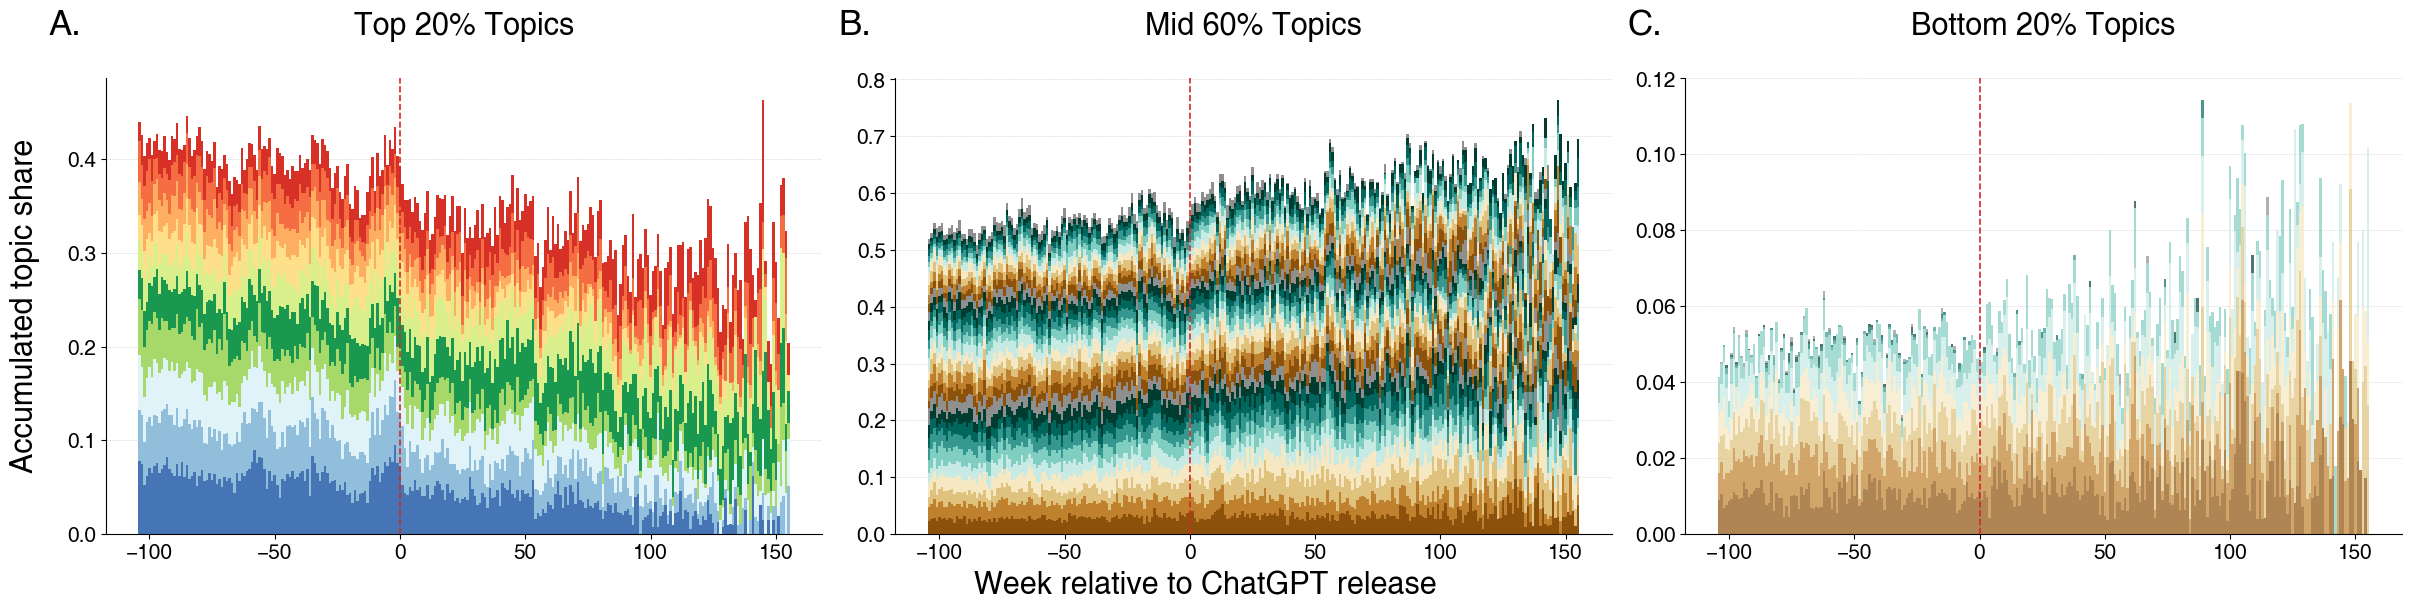

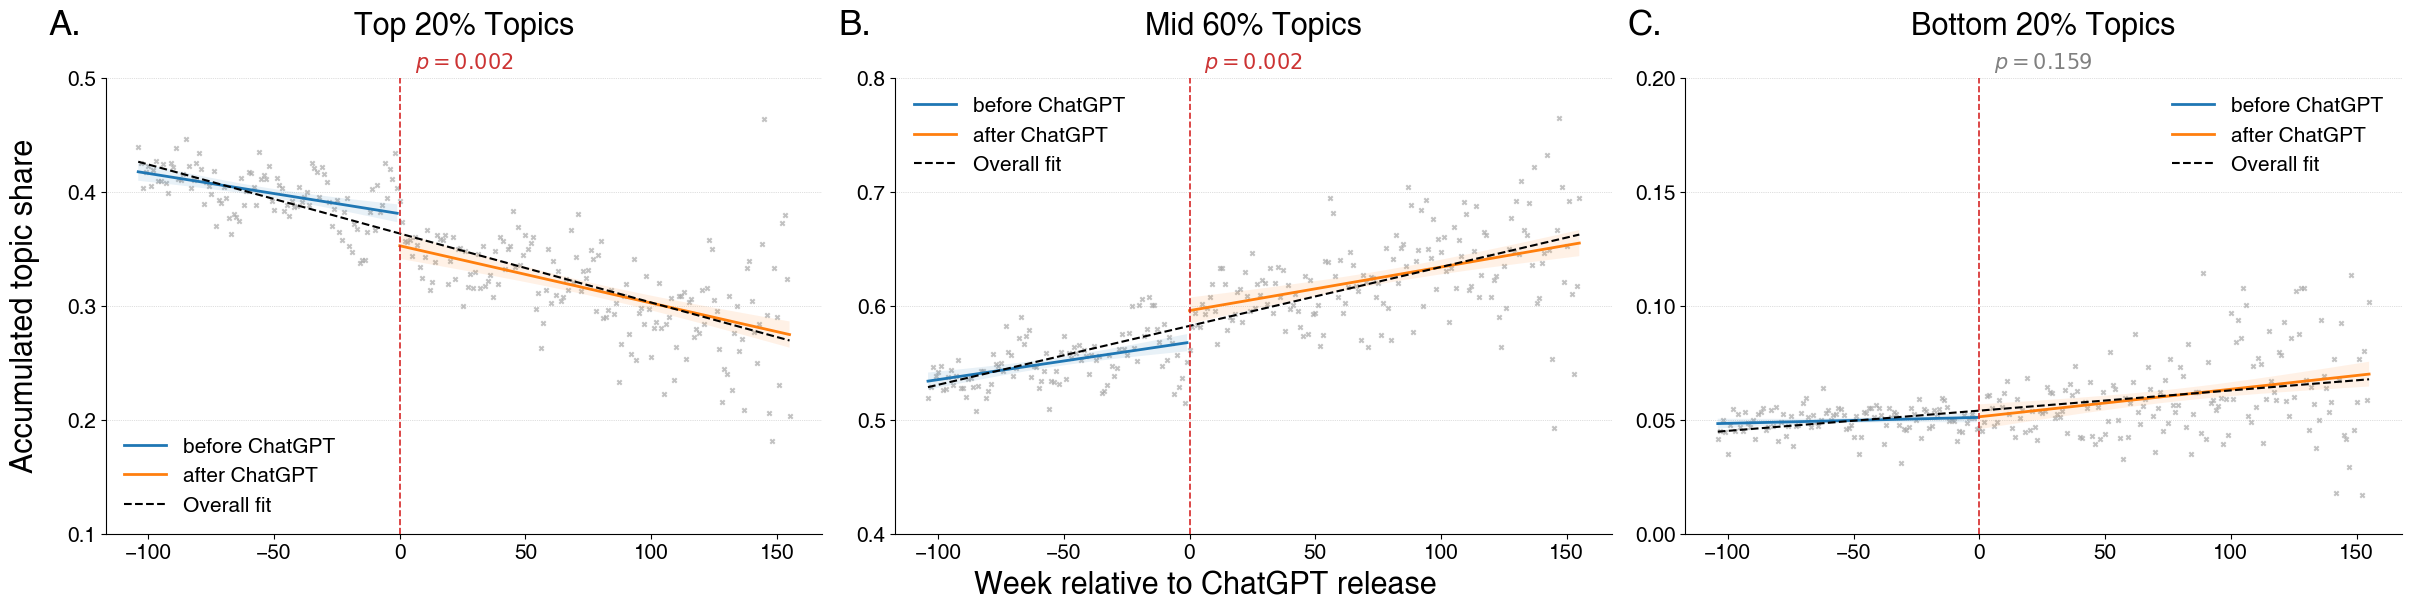

[Start....] drawing figures for c# language


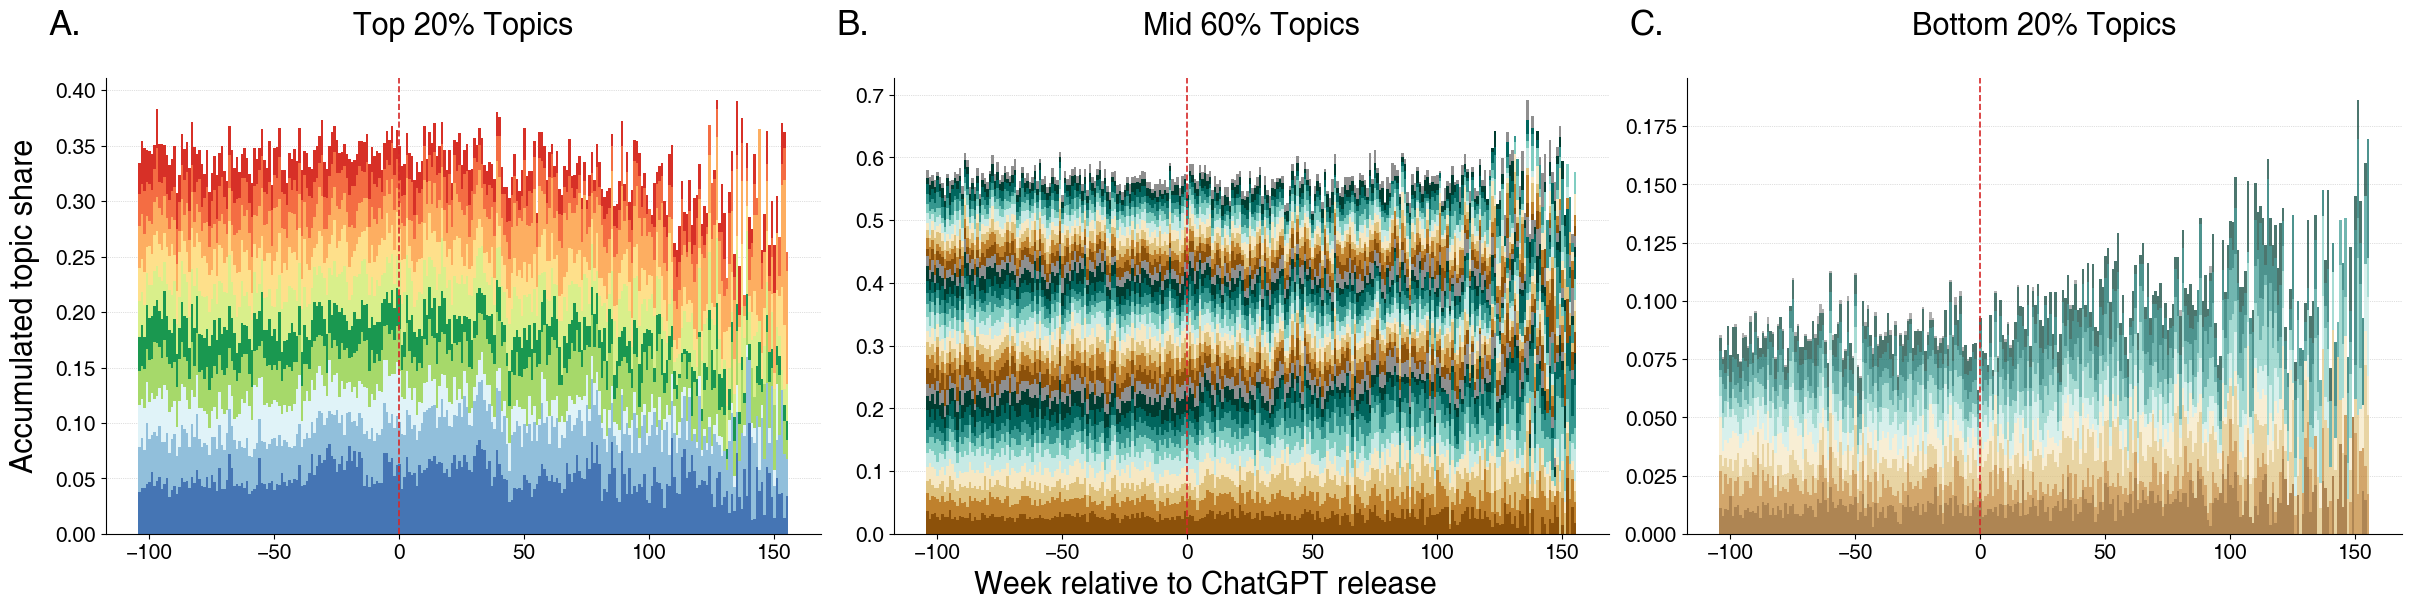

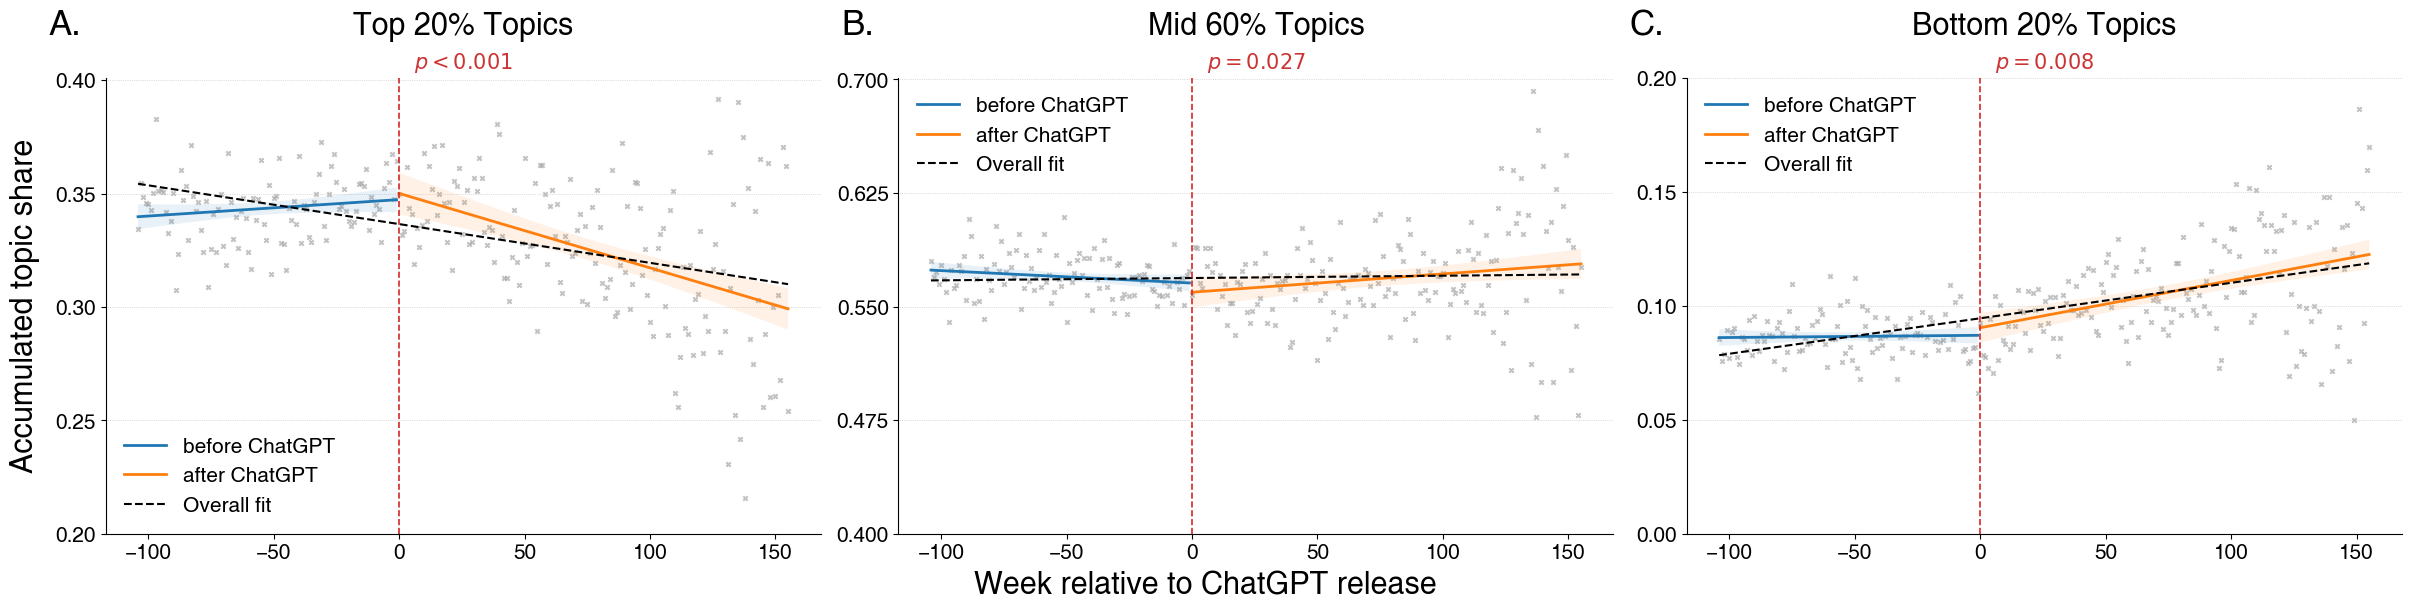

[Start....] drawing figures for c++ language


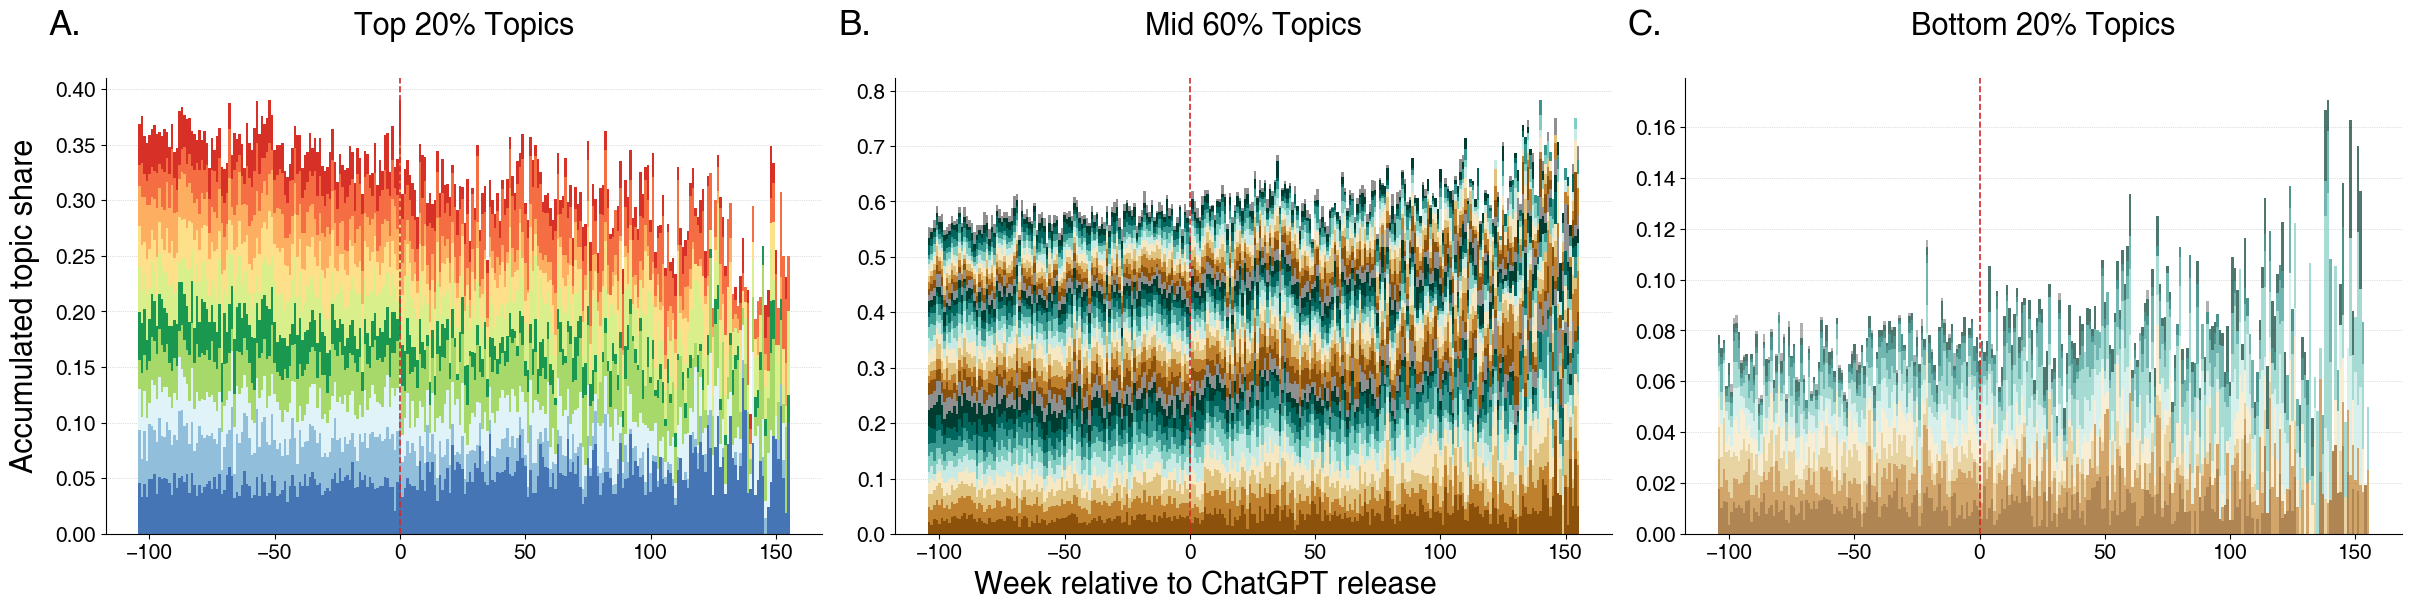

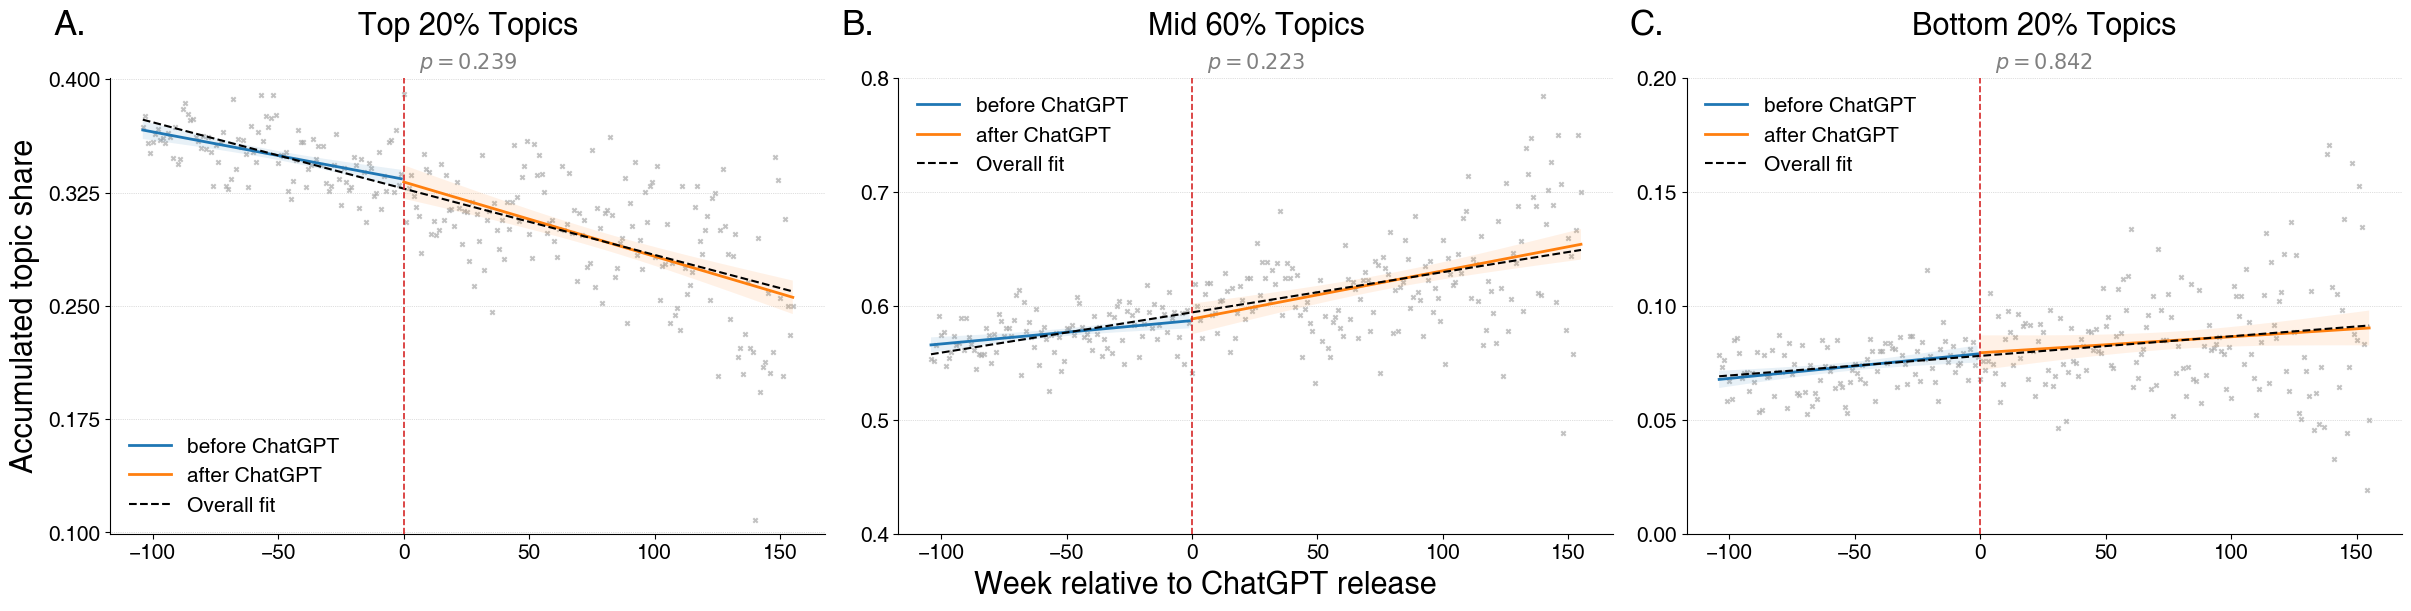

[Start....] drawing figures for c language


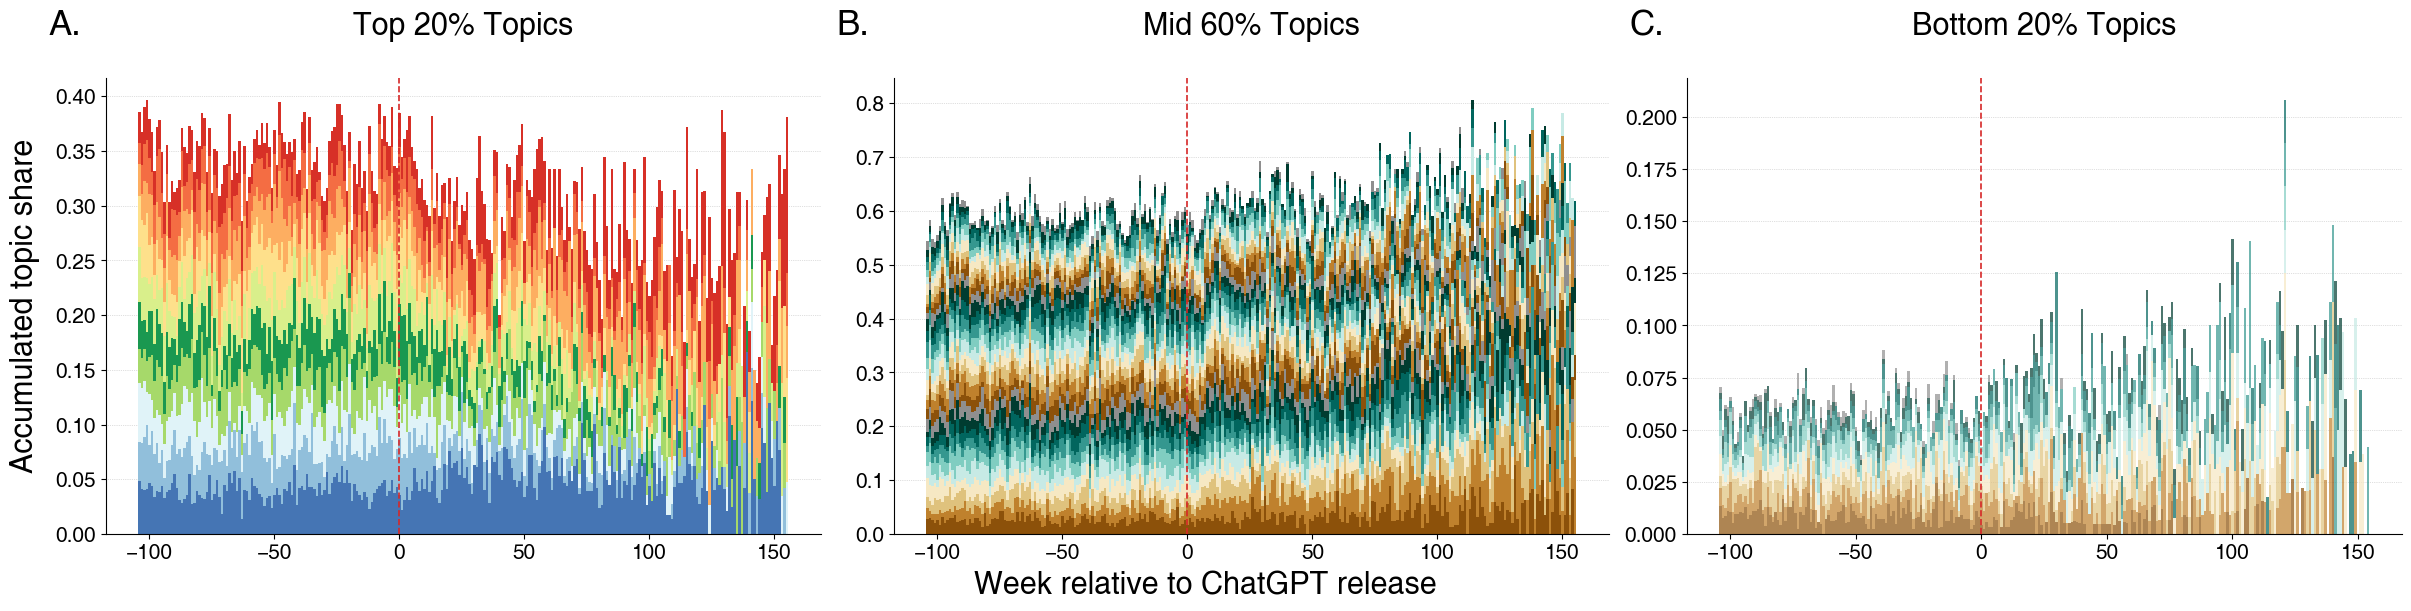

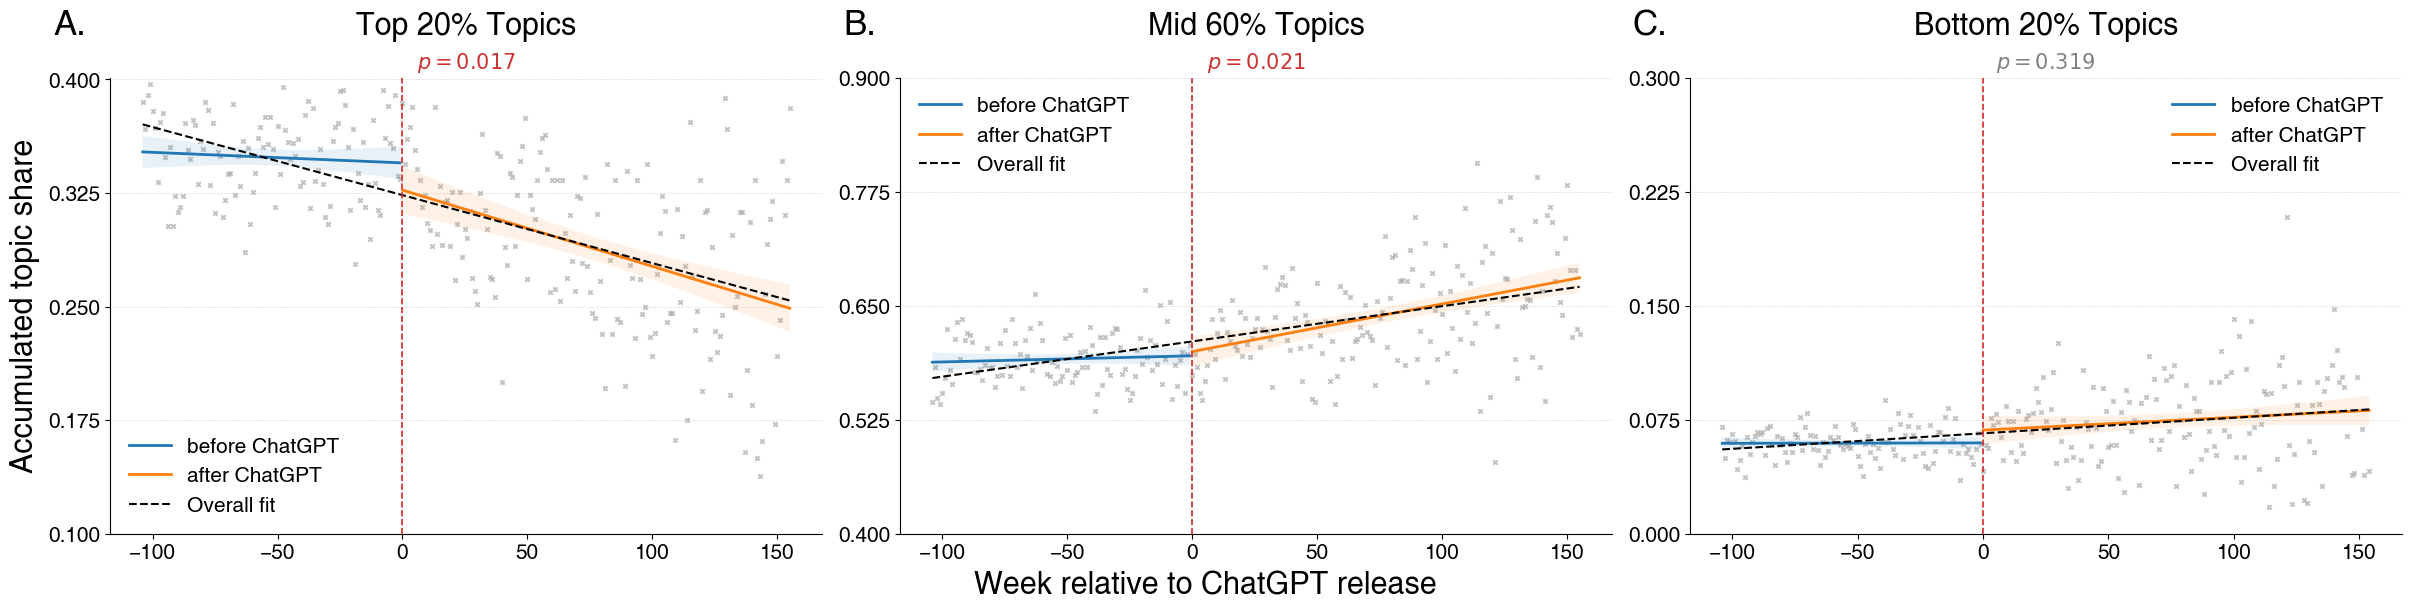

[Start....] drawing figures for r language


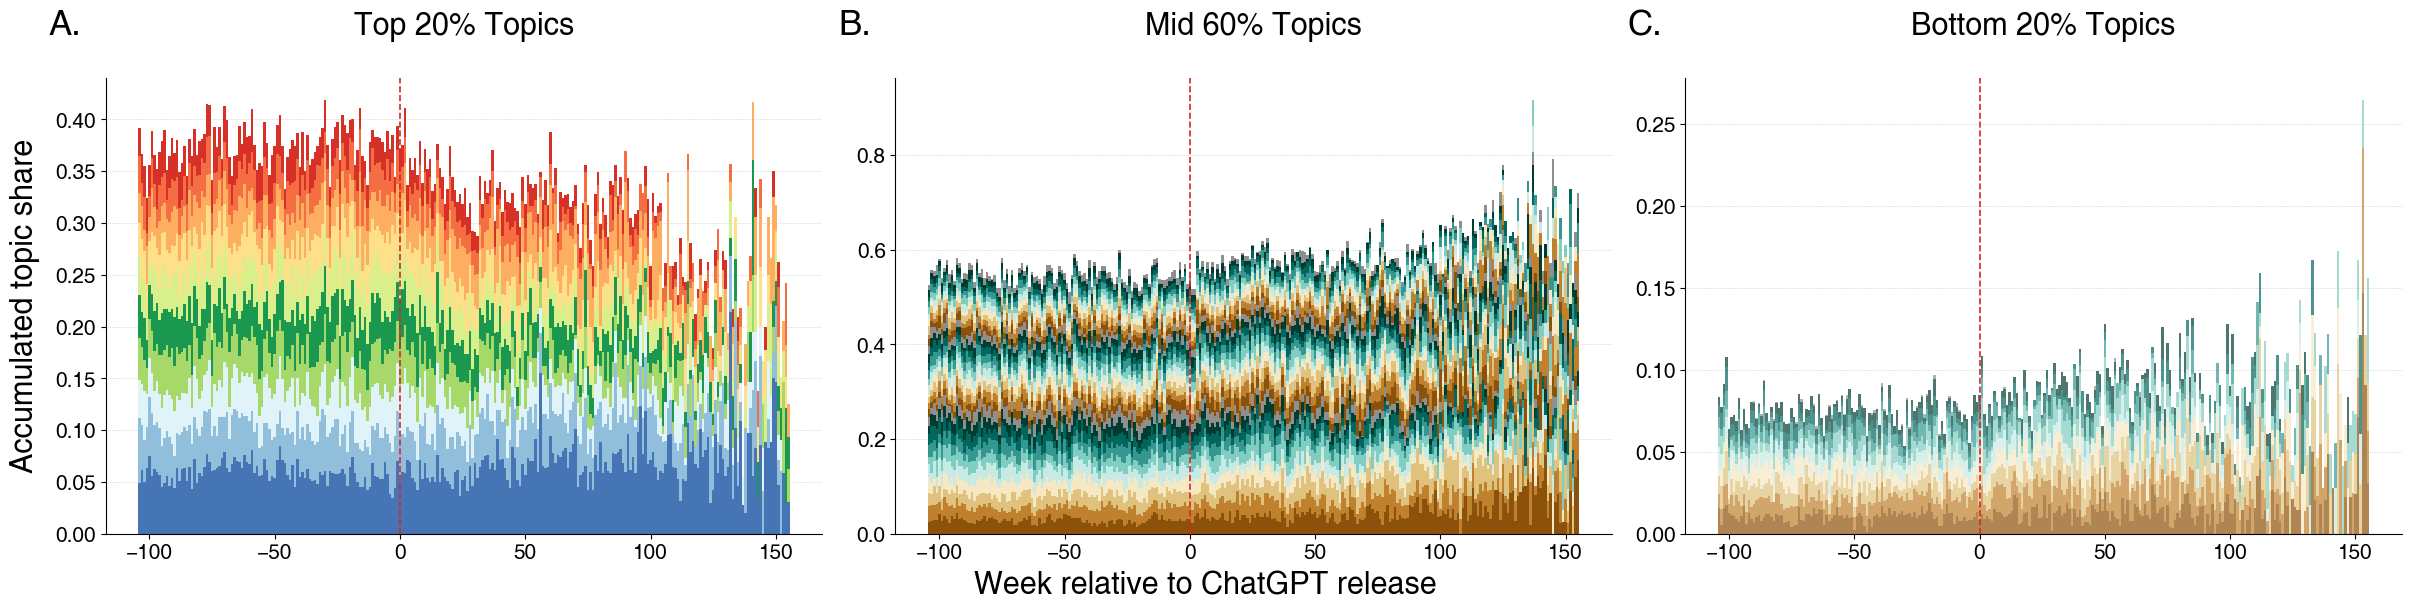

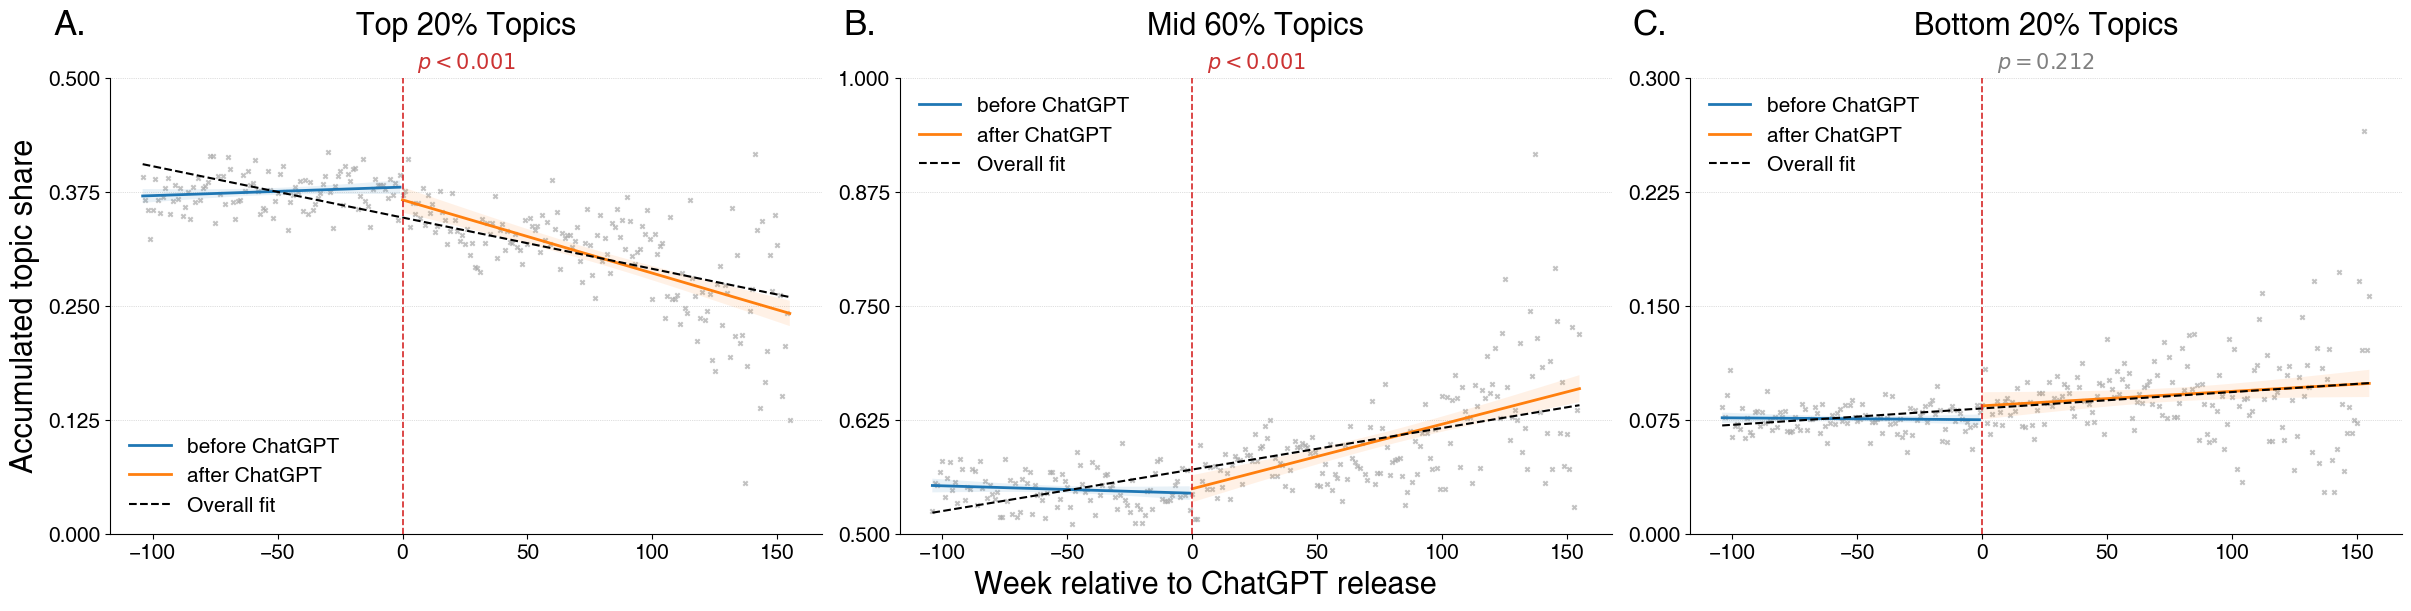

[Start....] drawing figures for php language


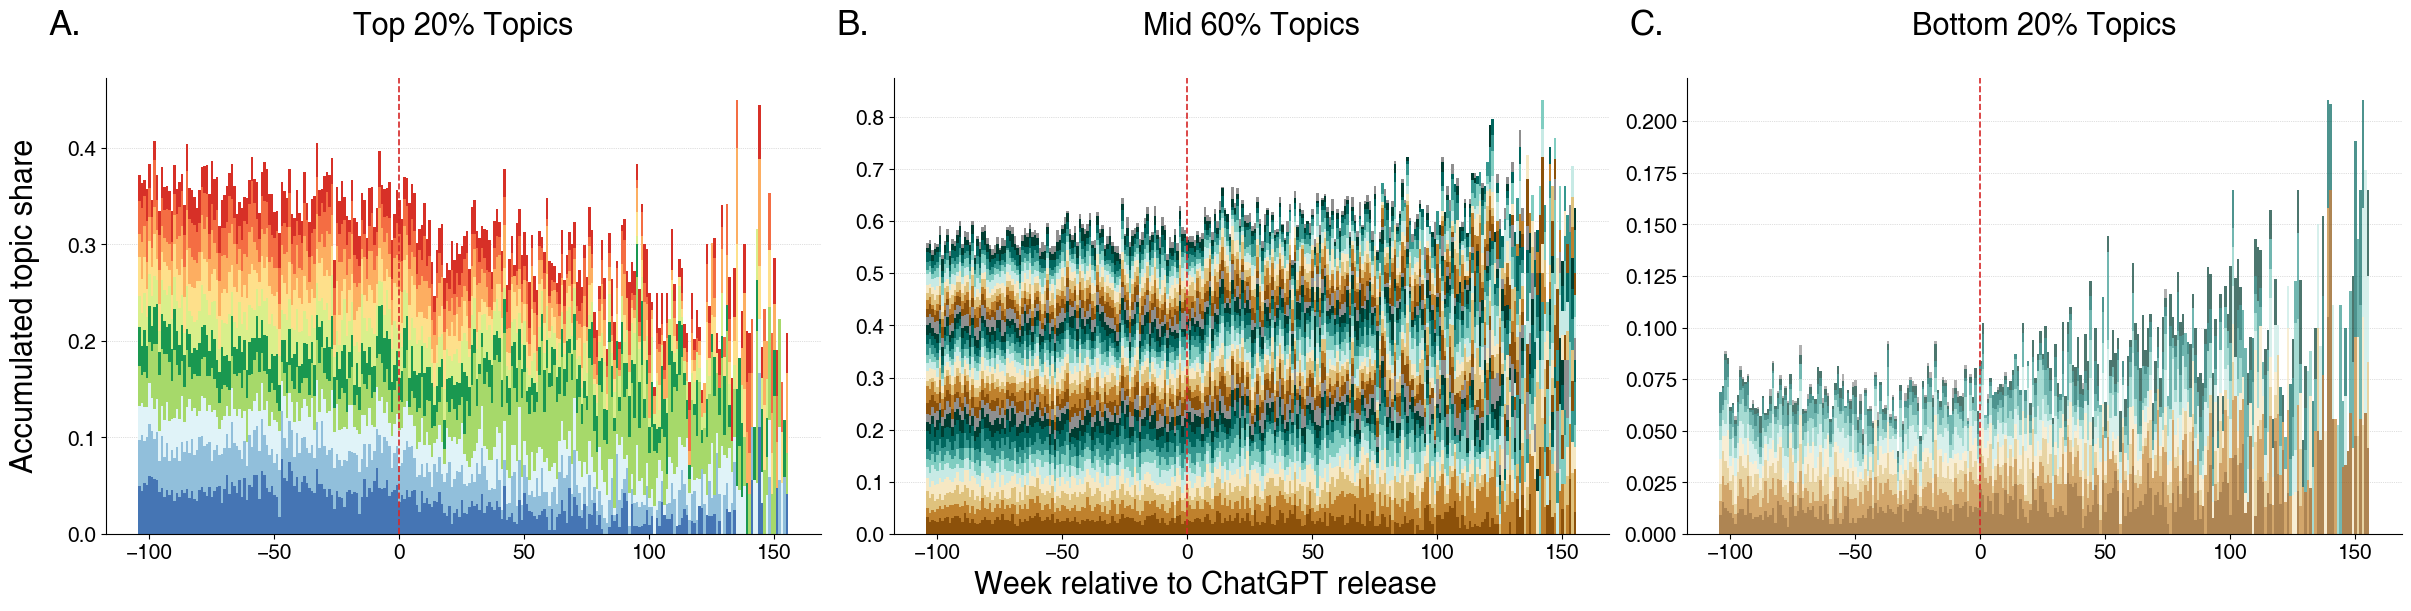

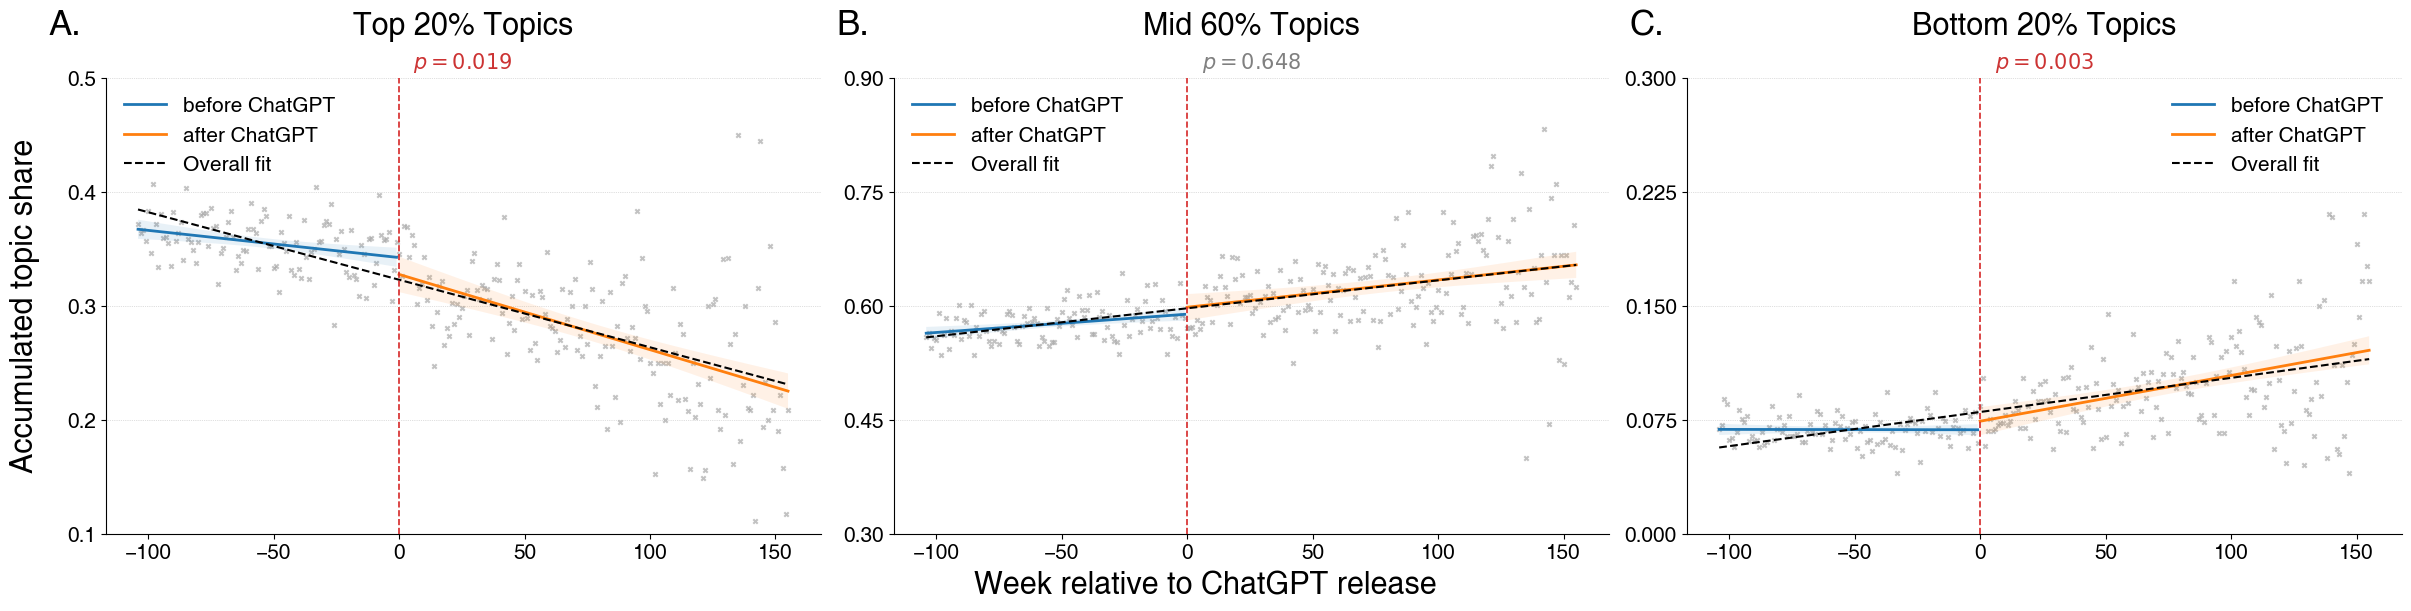

[Start....] drawing figures for swift language


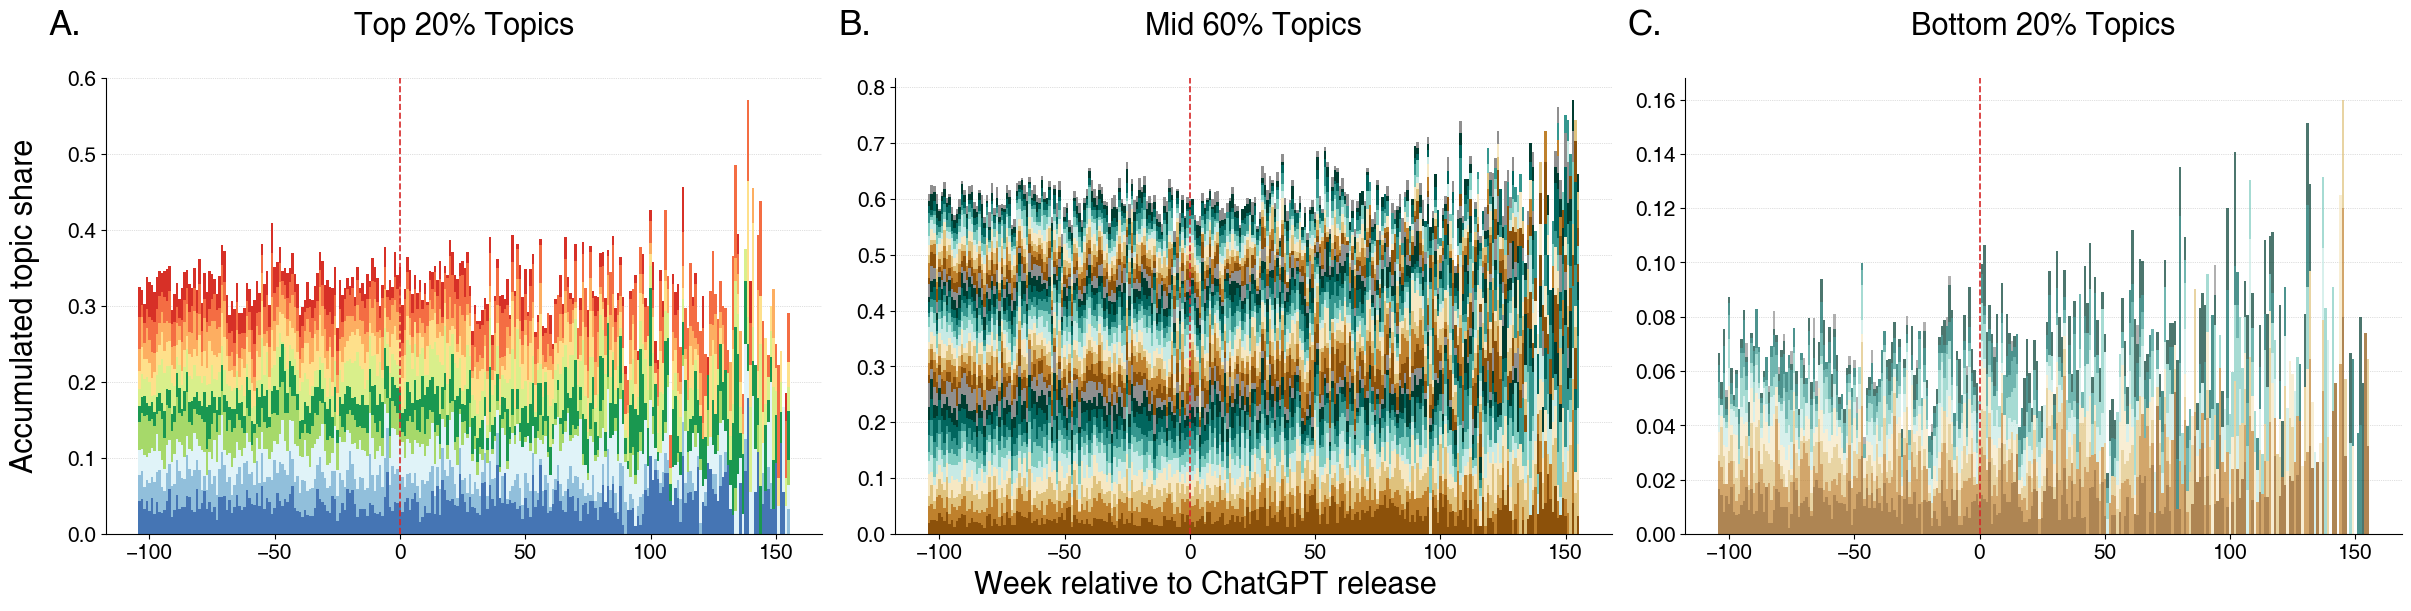

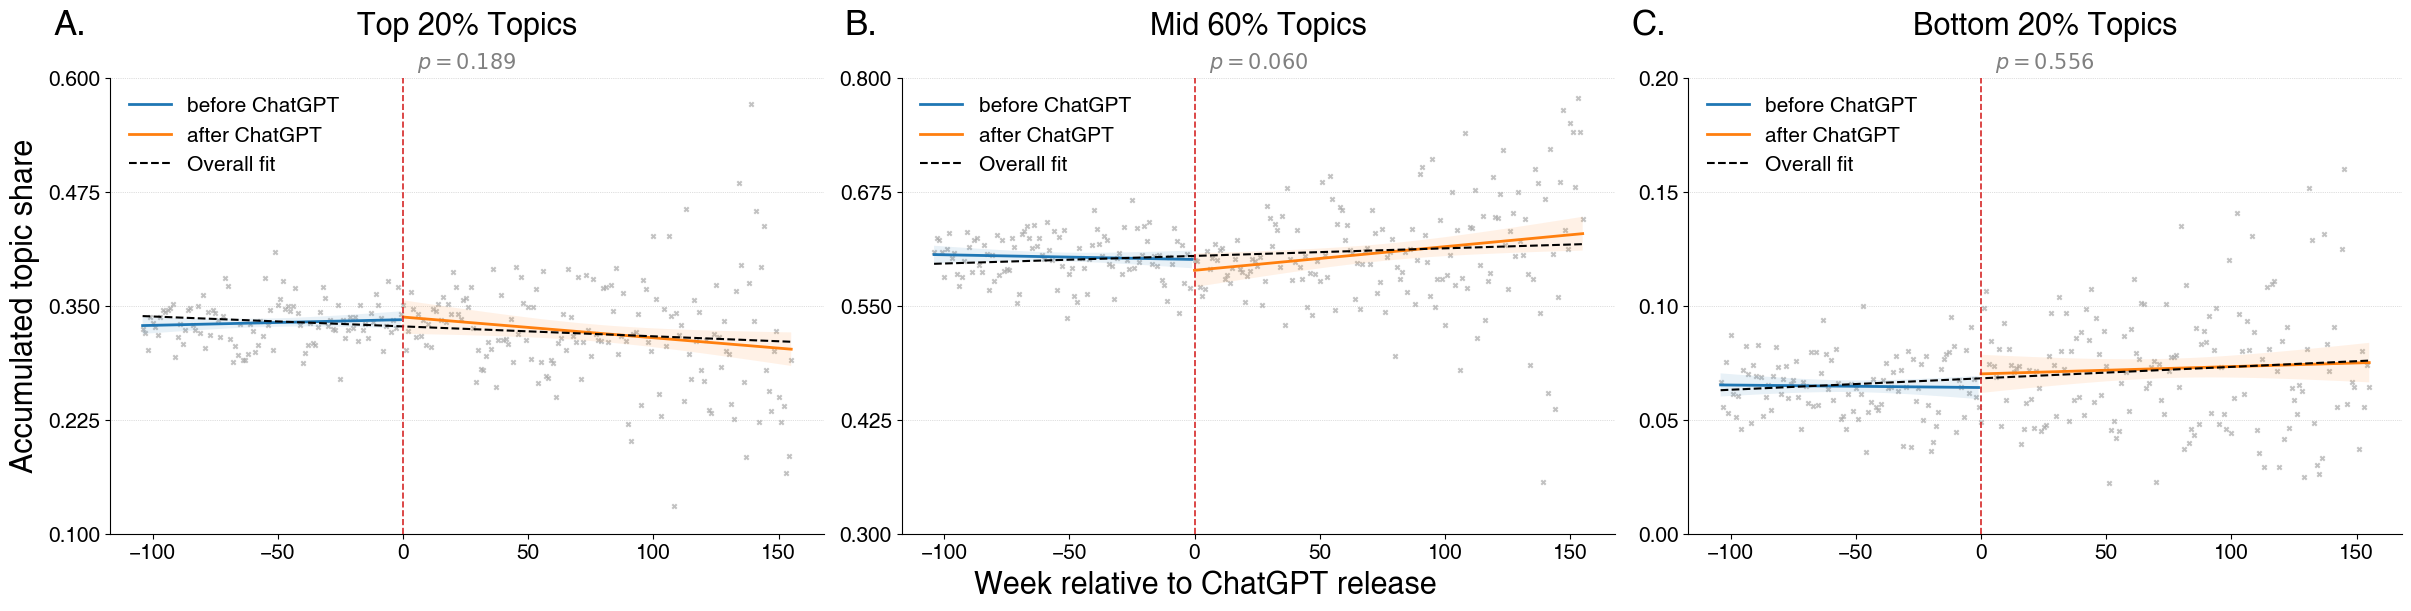

[Start....] drawing figures for kotlin language


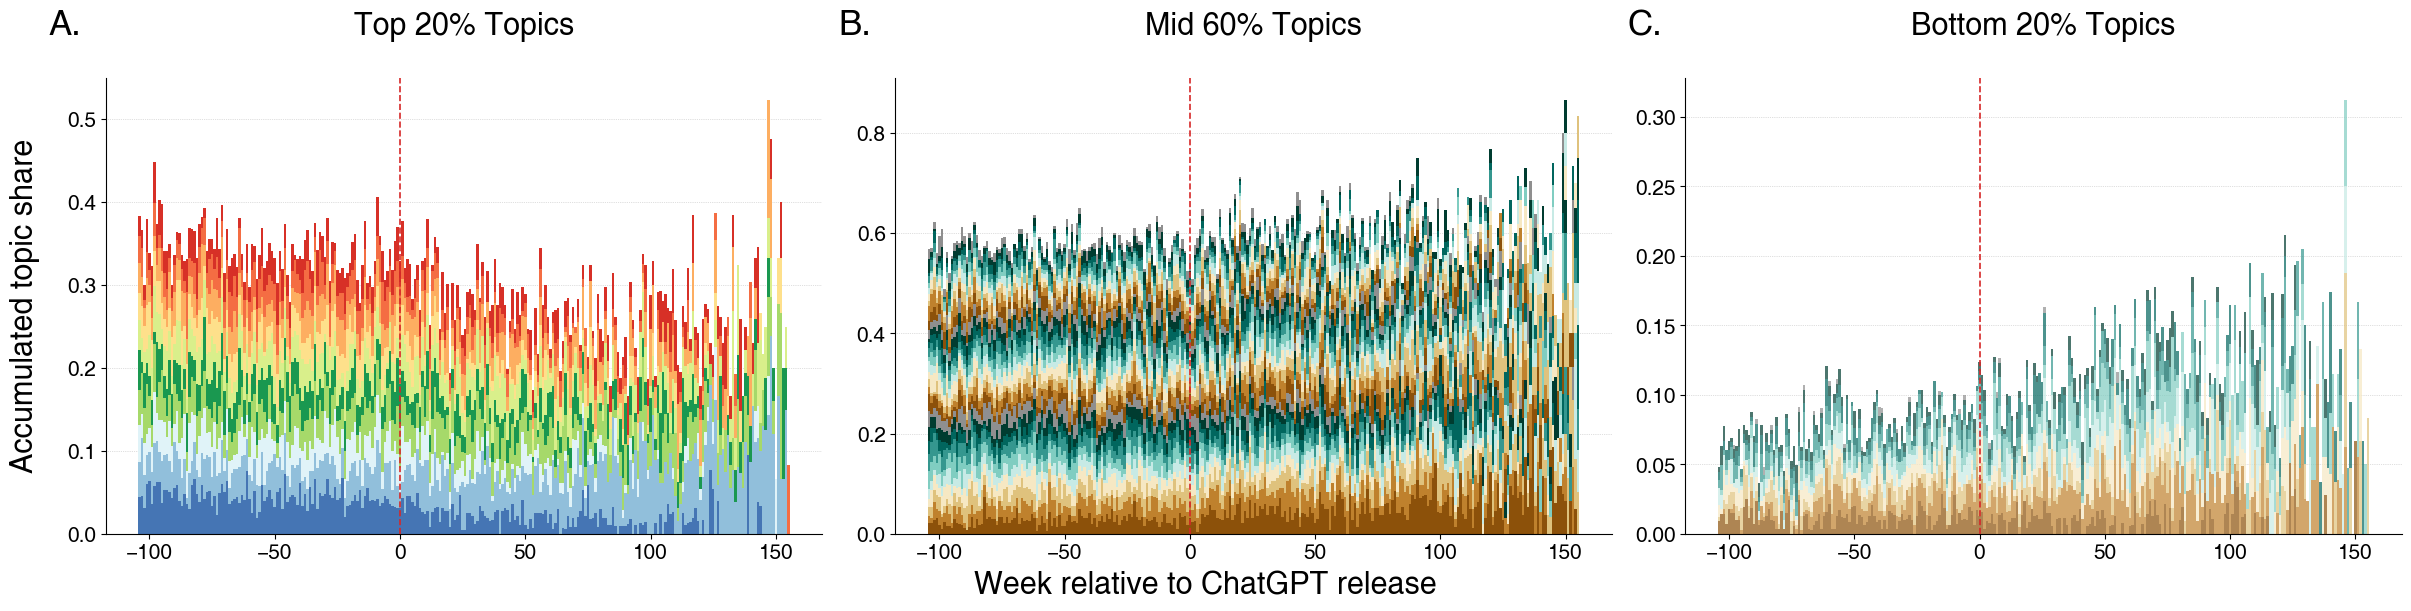

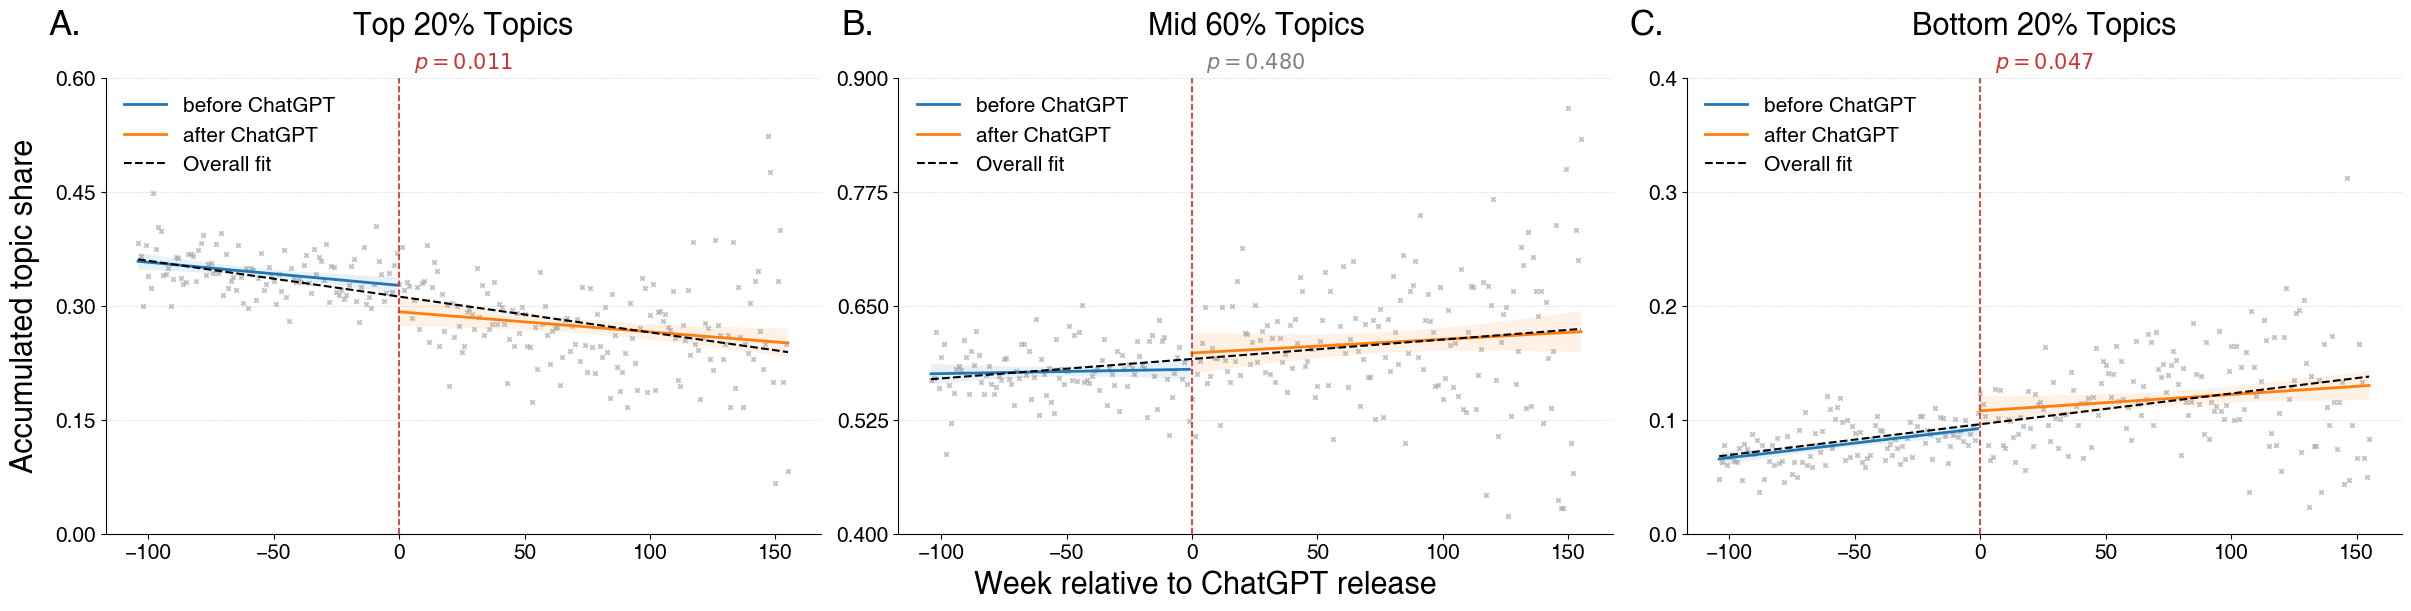

[Start....] drawing figures for dart language


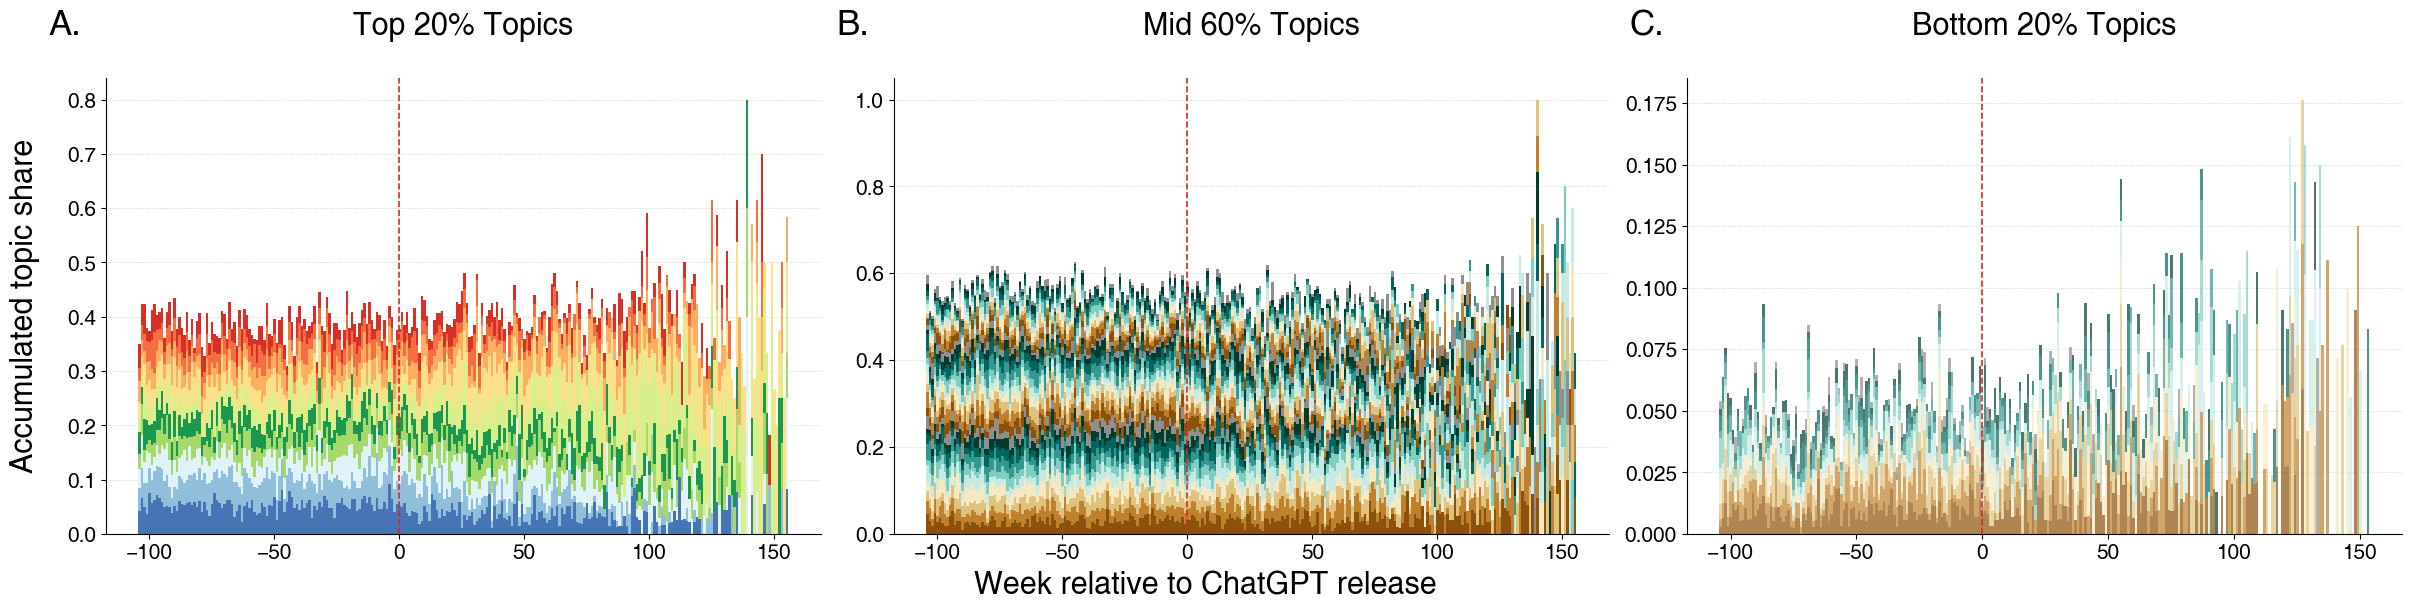

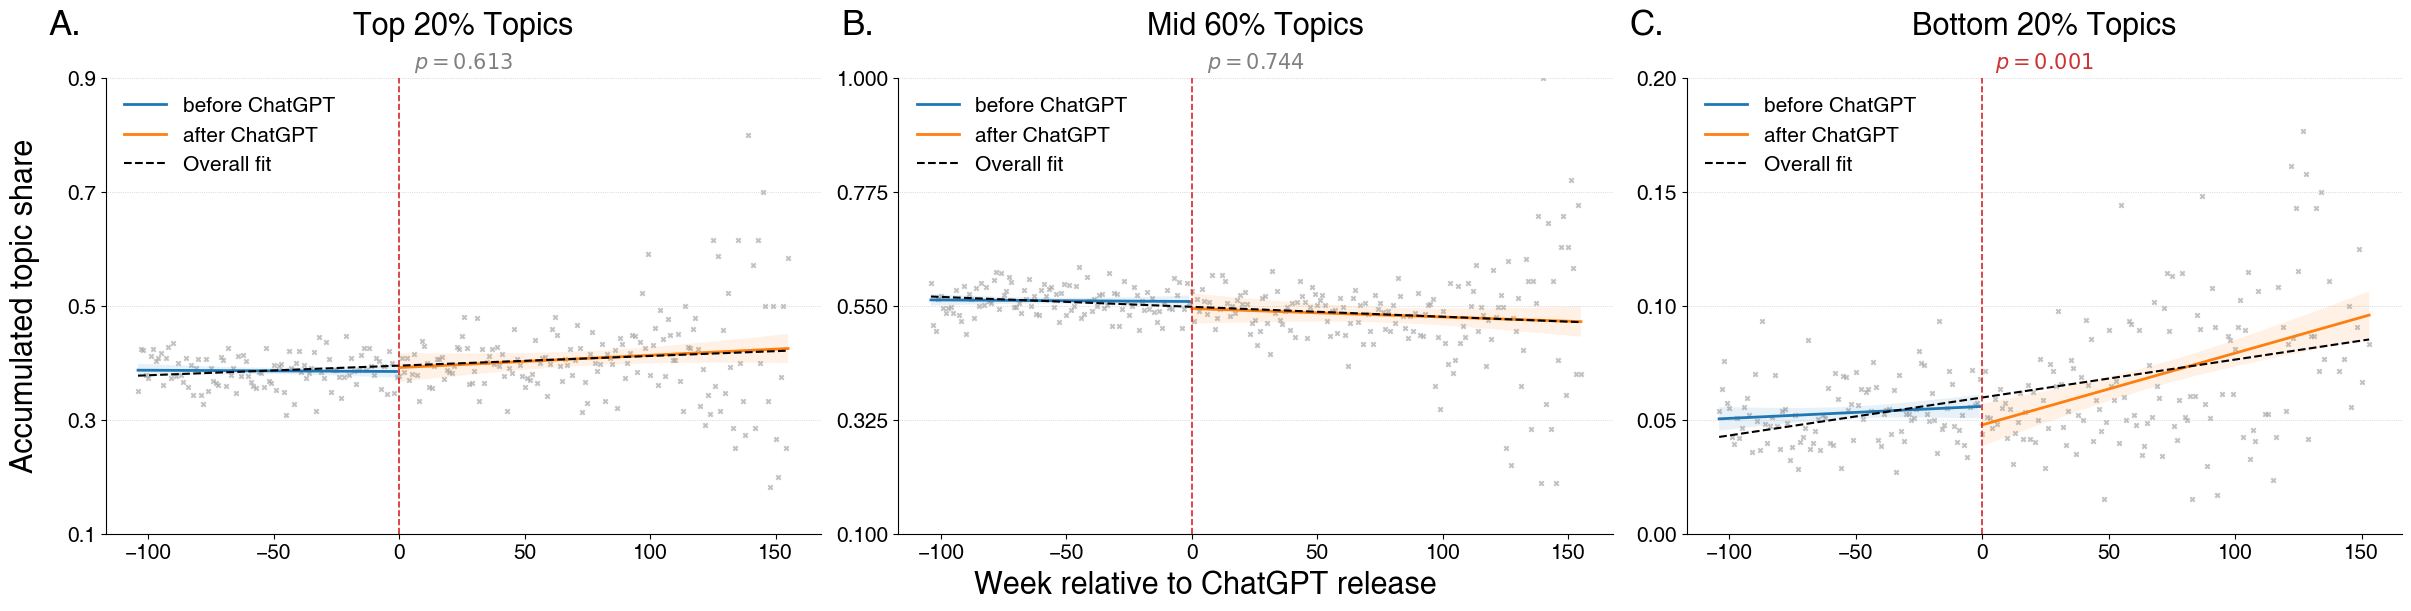

[Start....] drawing figures for typescript language


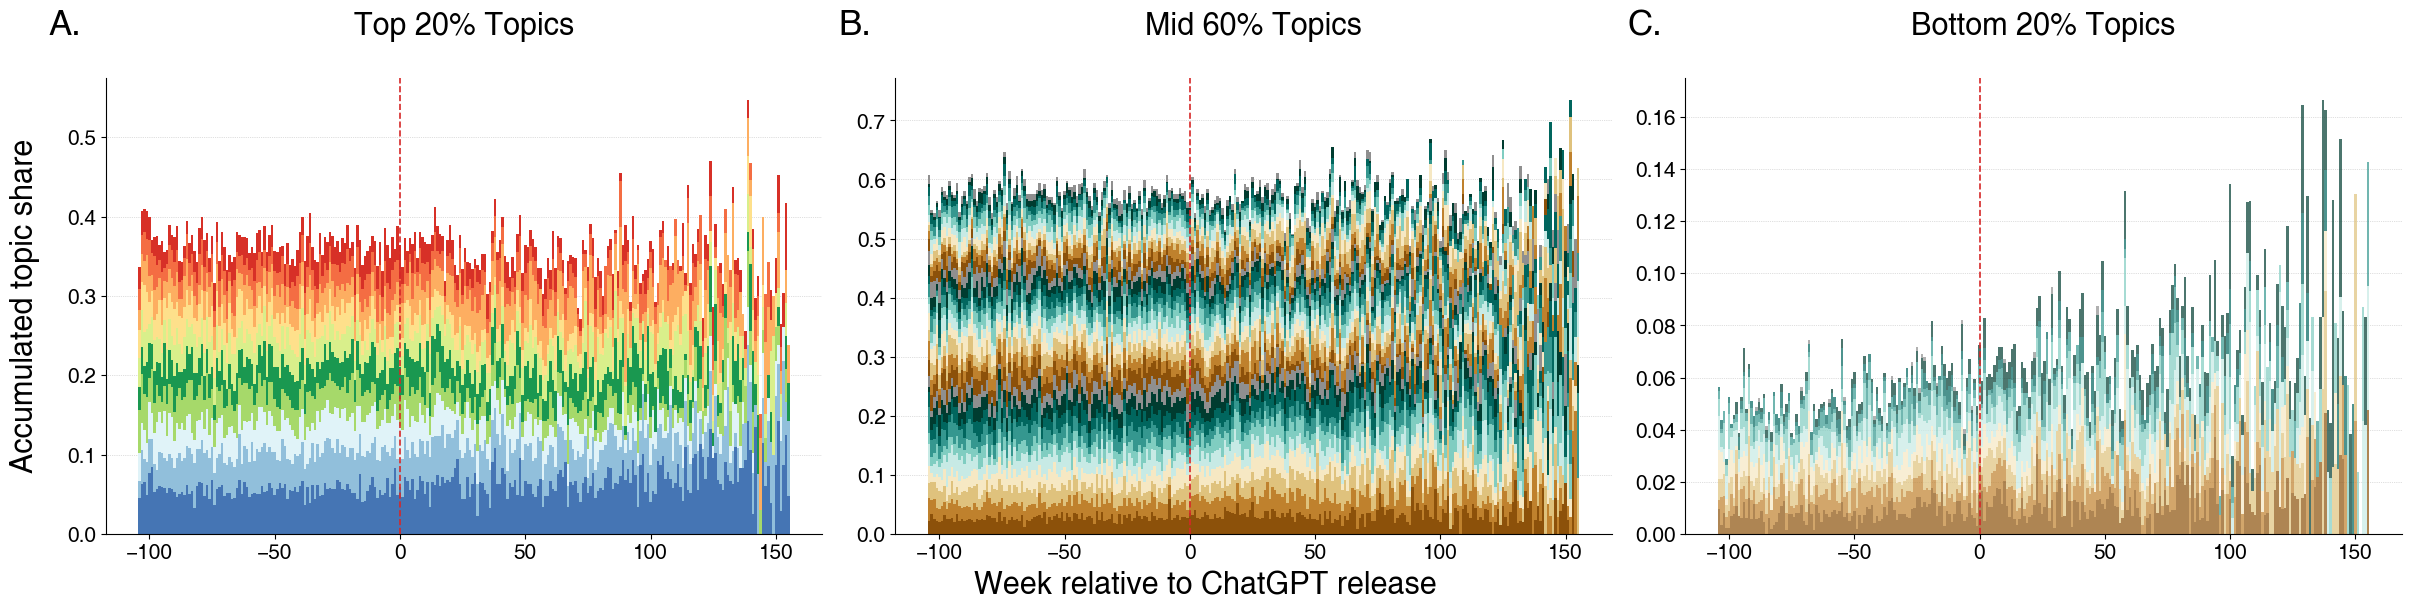

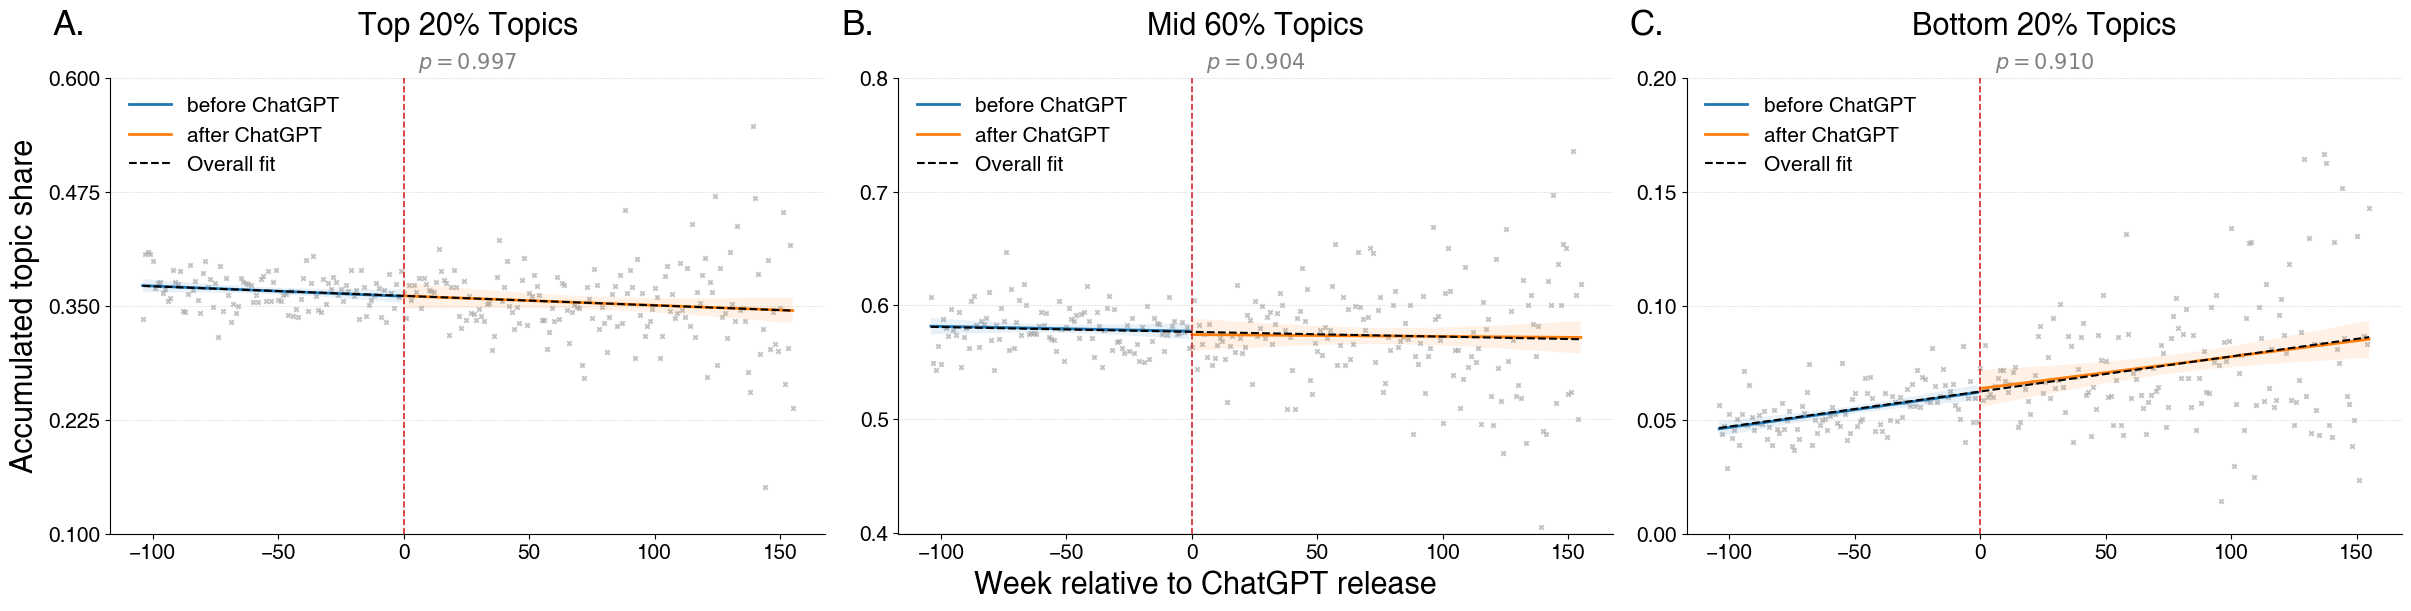

[Start....] drawing figures for go language


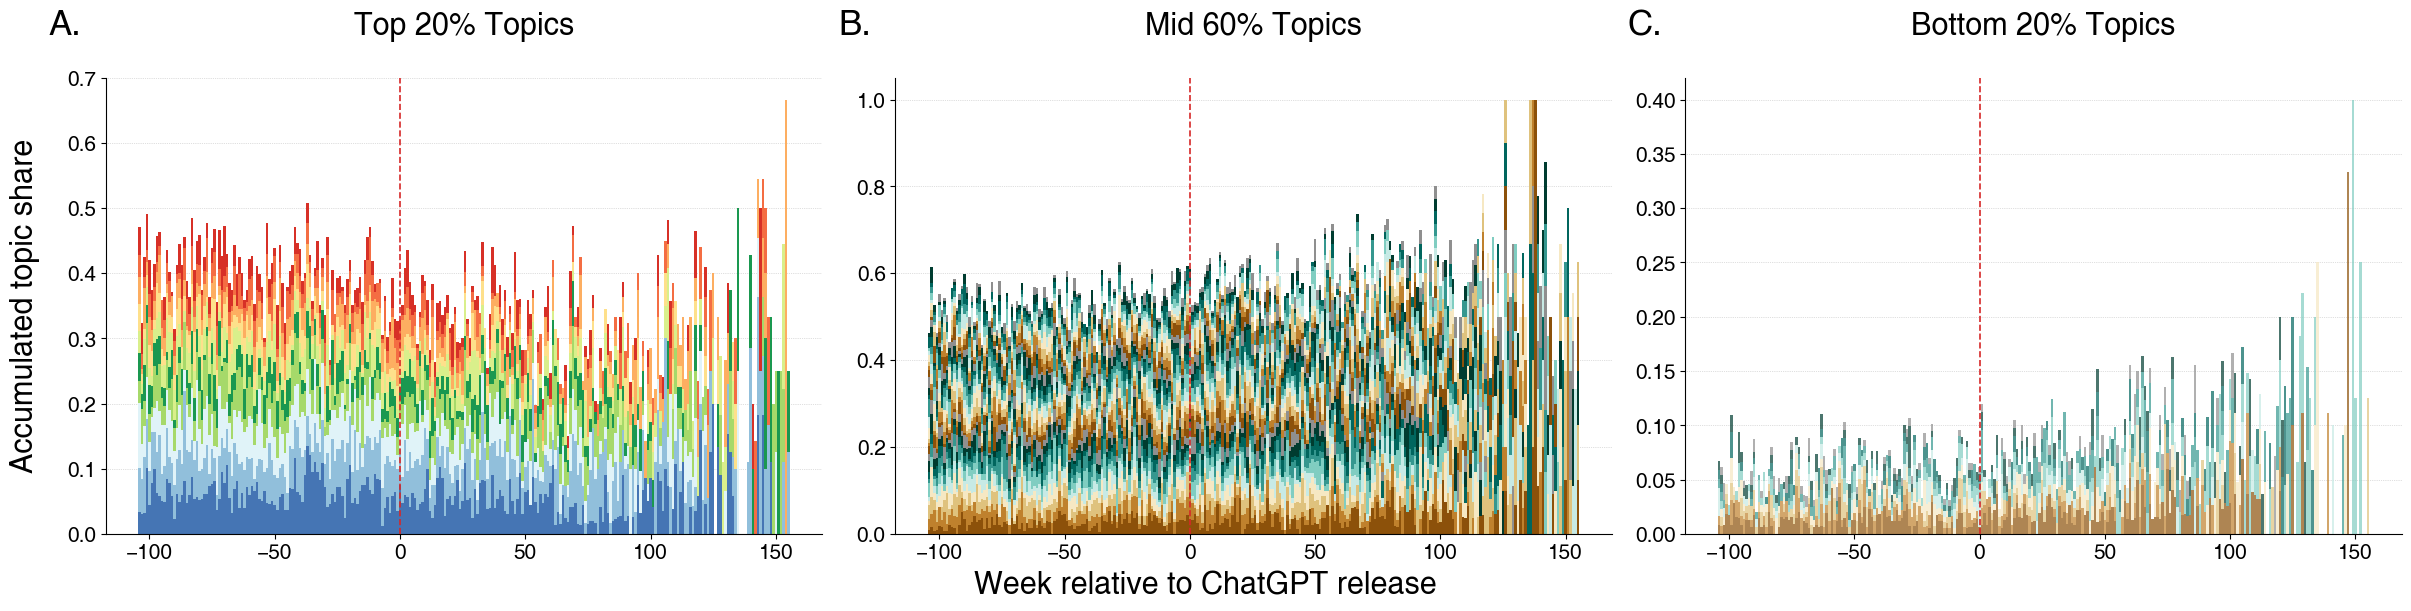

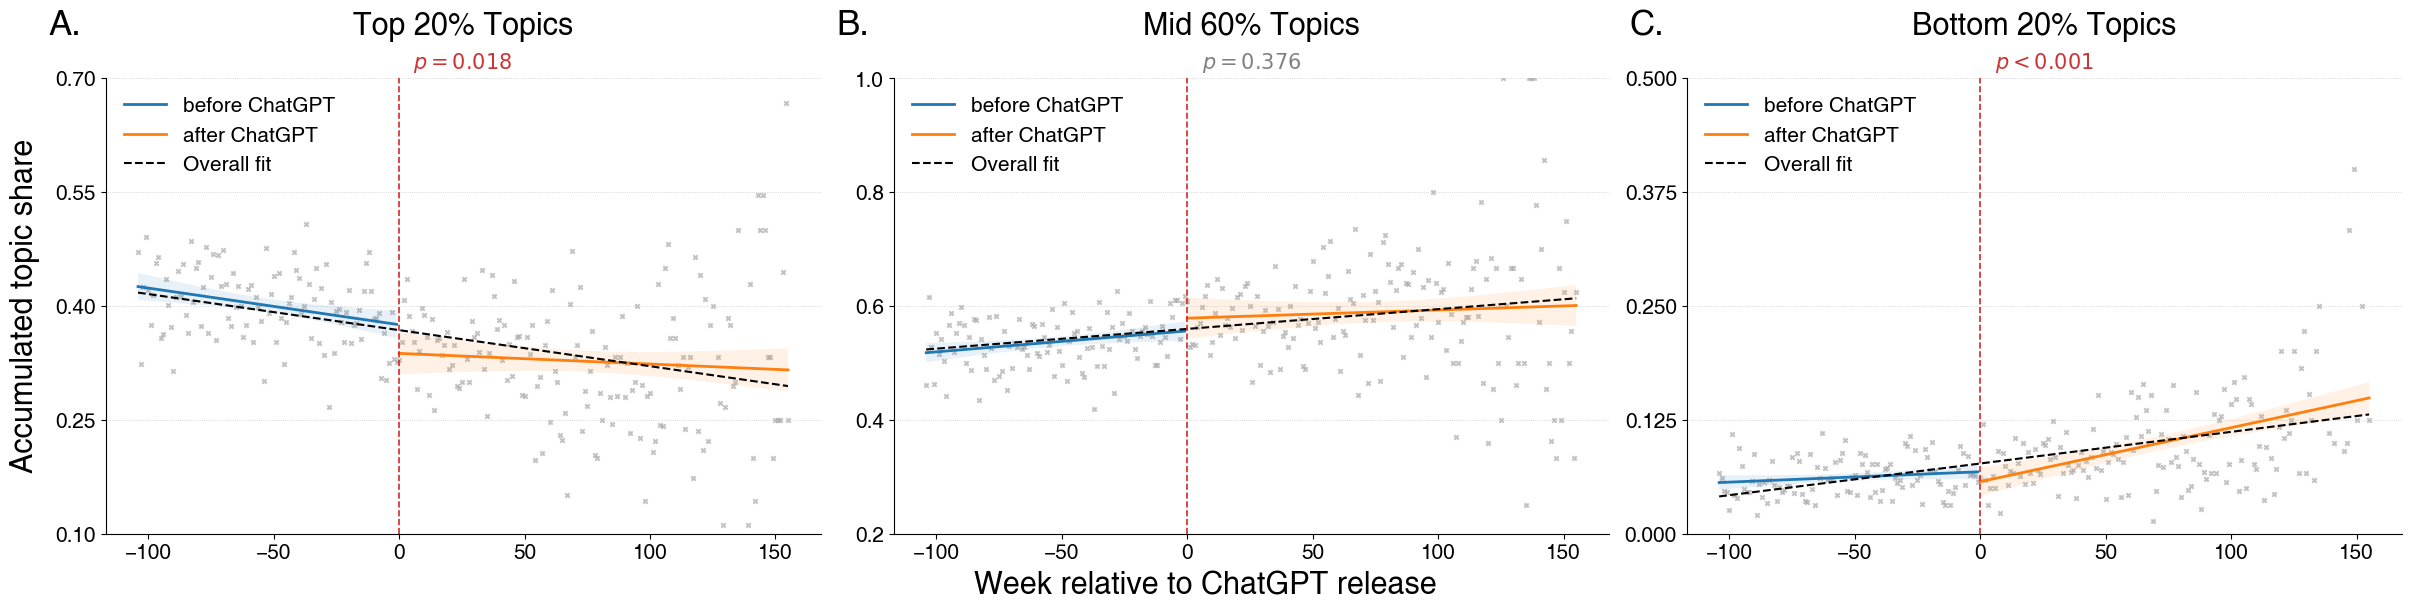

[Start....] drawing figures for ruby language


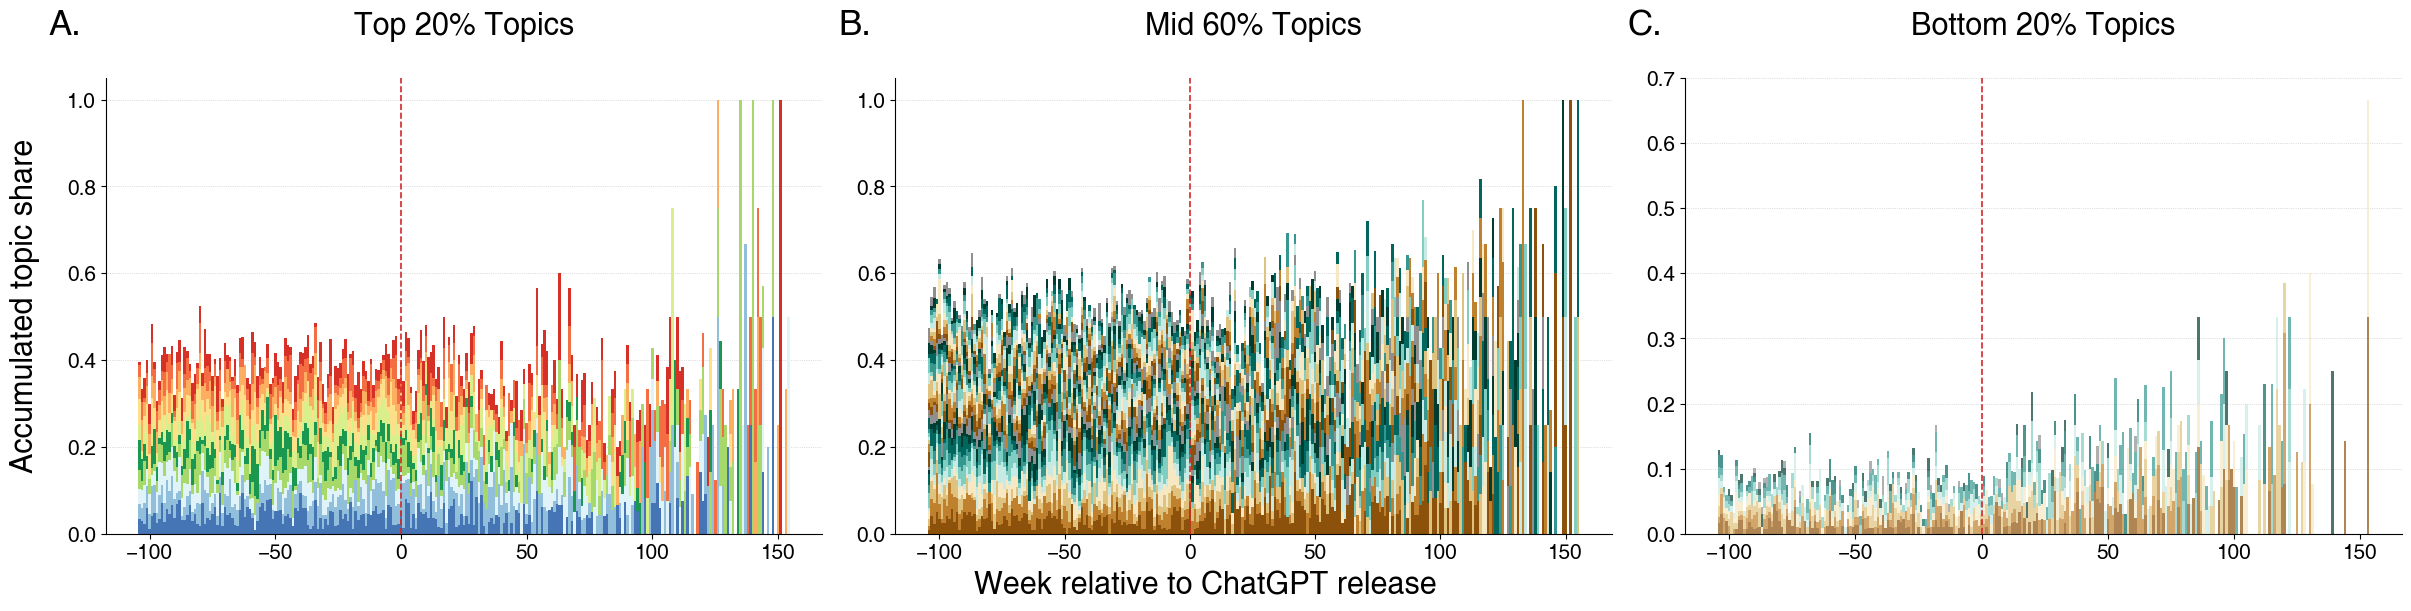

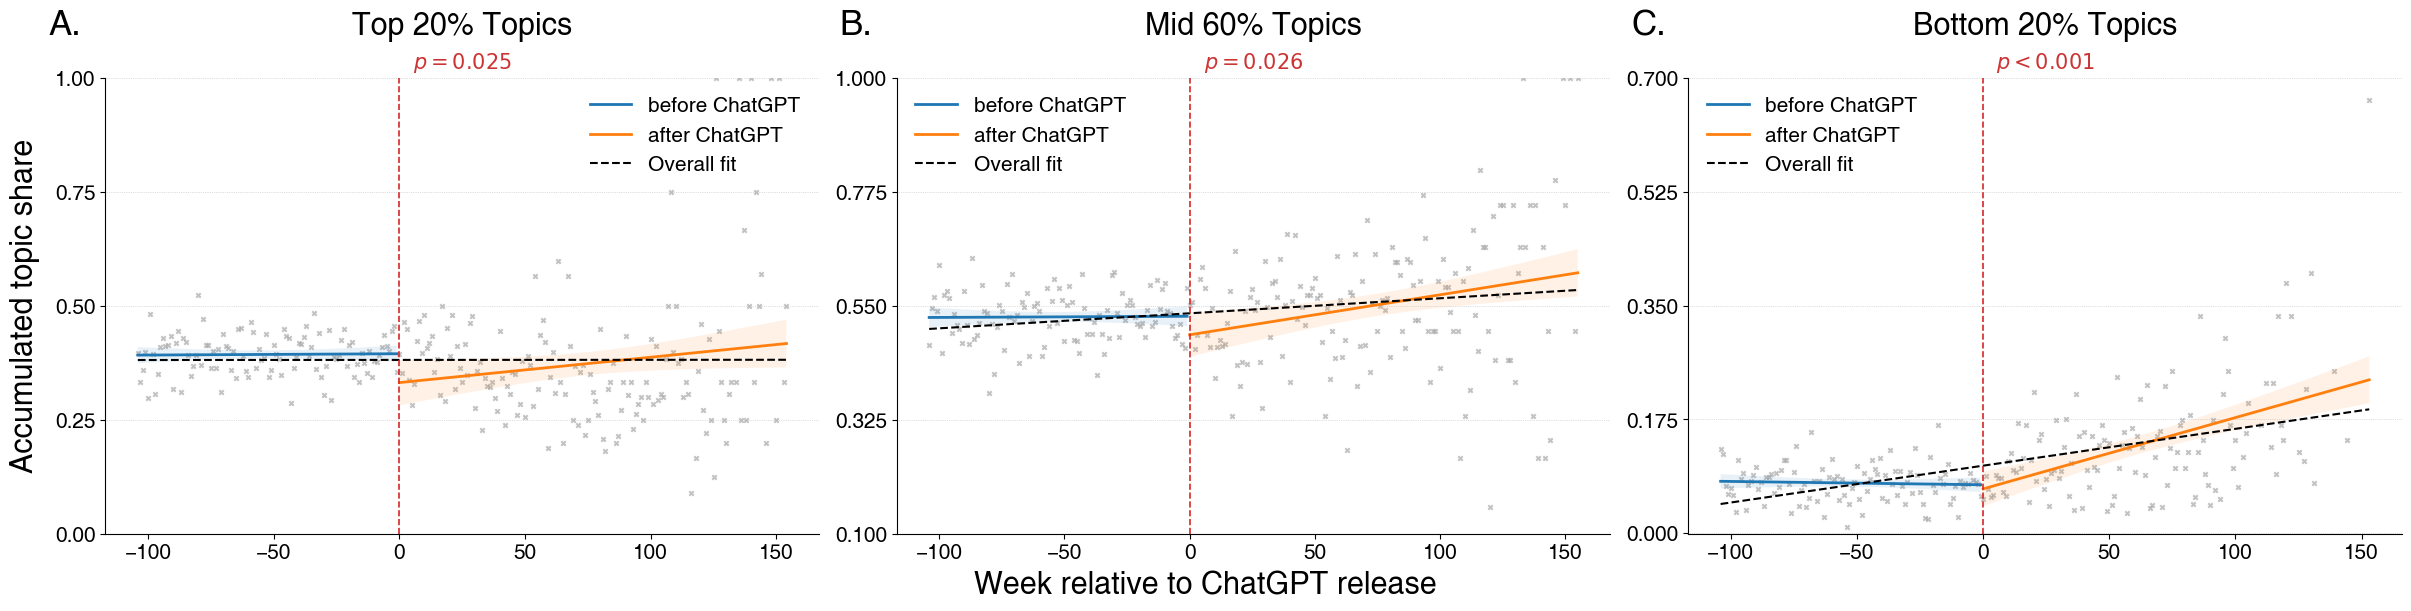

[Start....] drawing figures for rust language


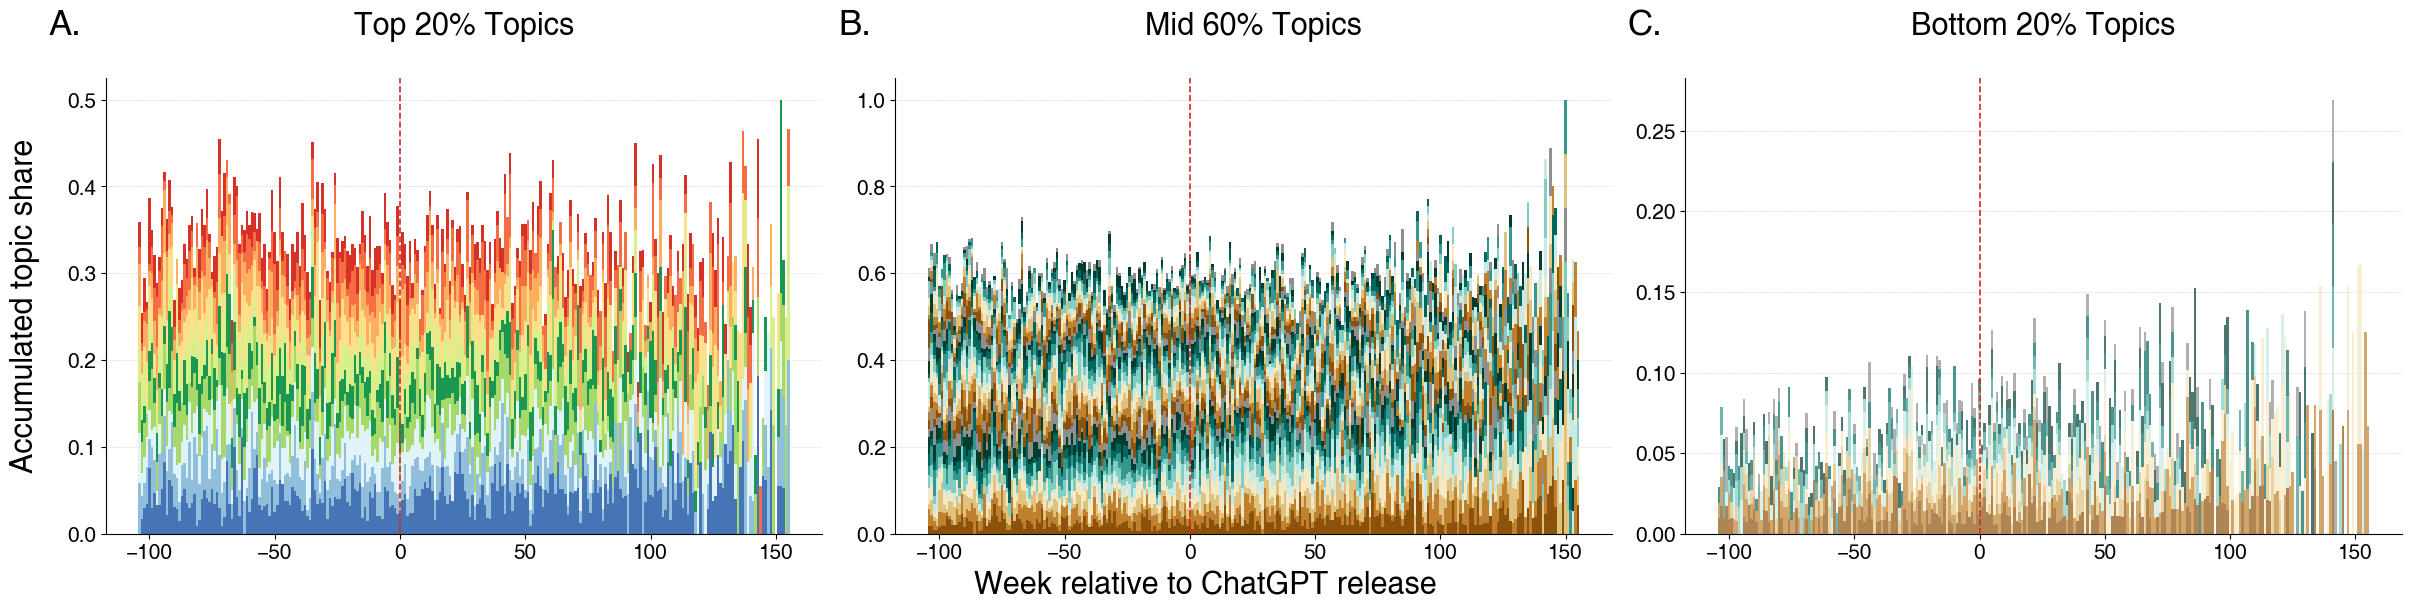

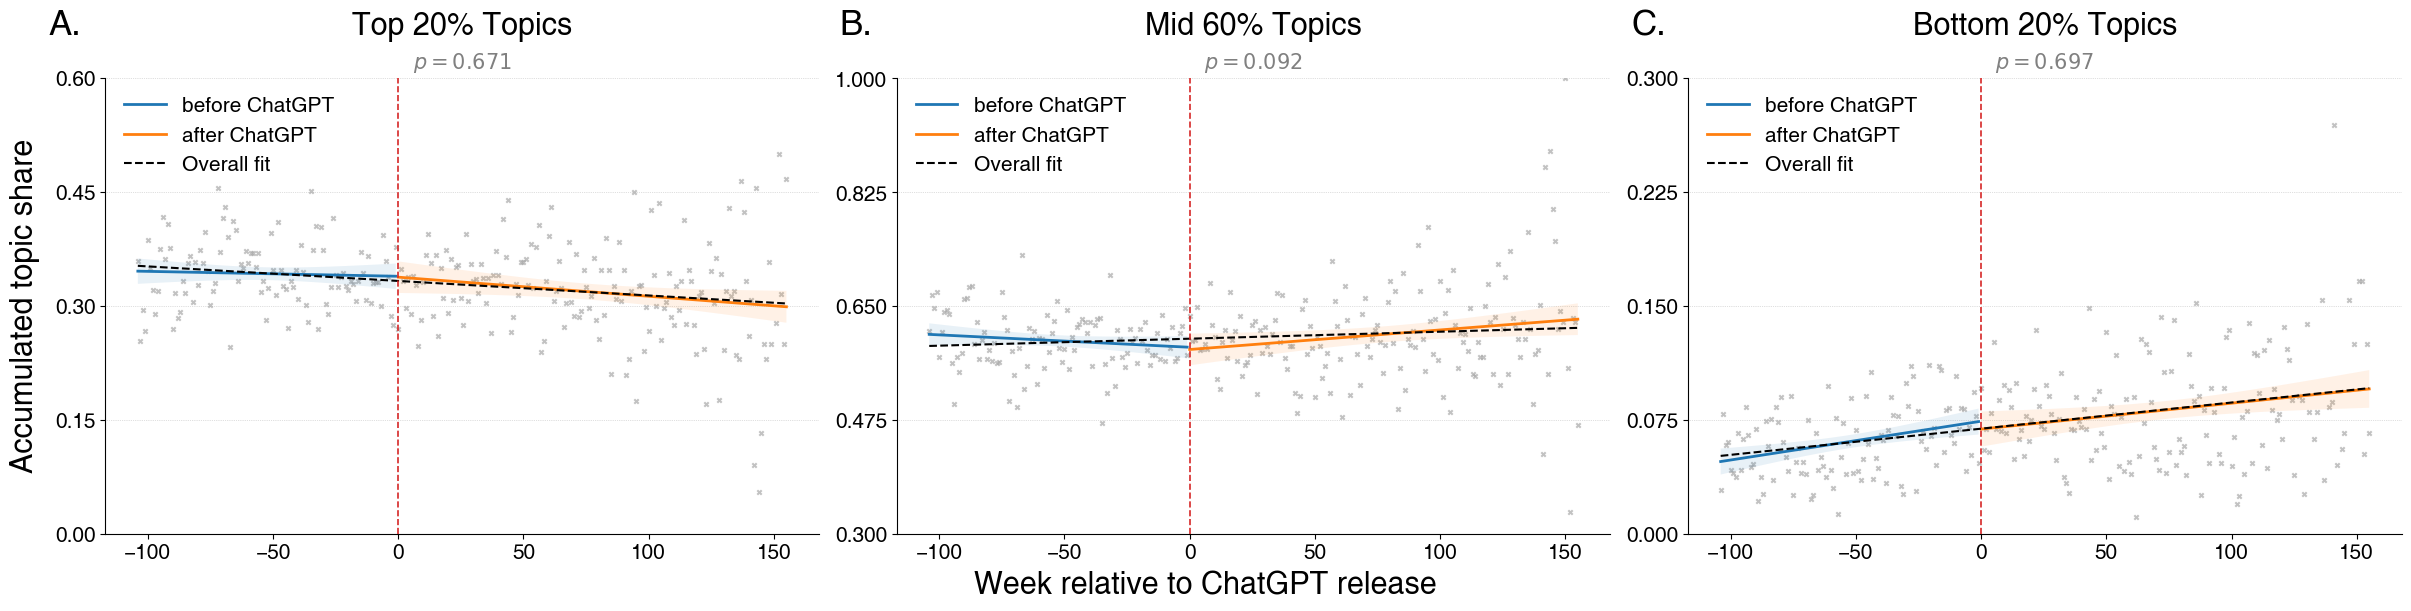

[Start....] drawing figures for scala language


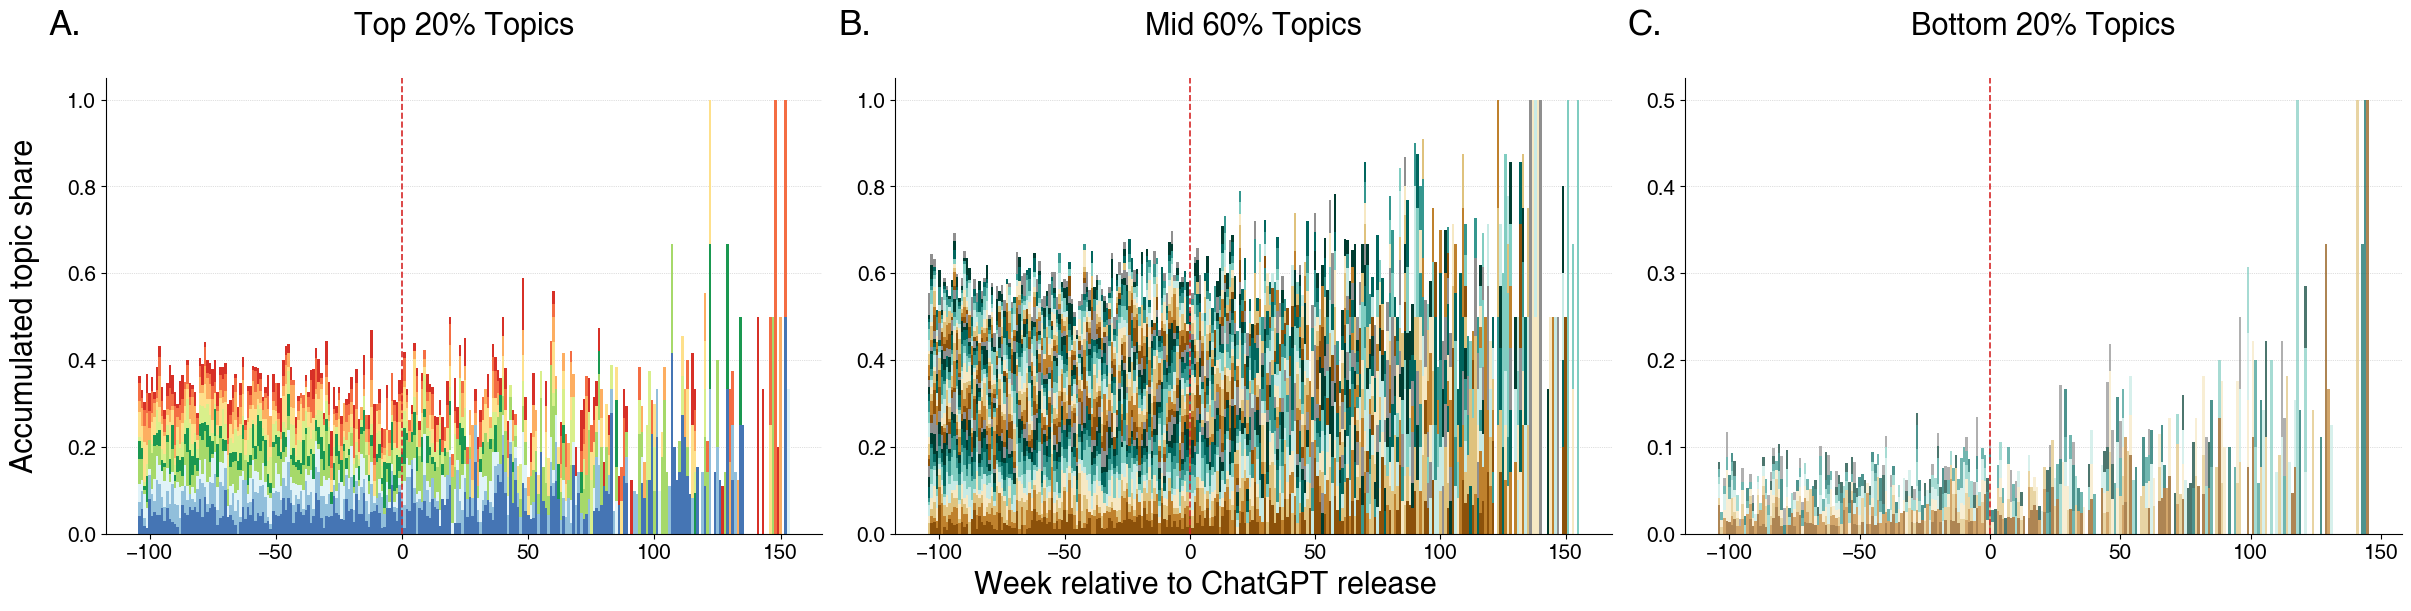

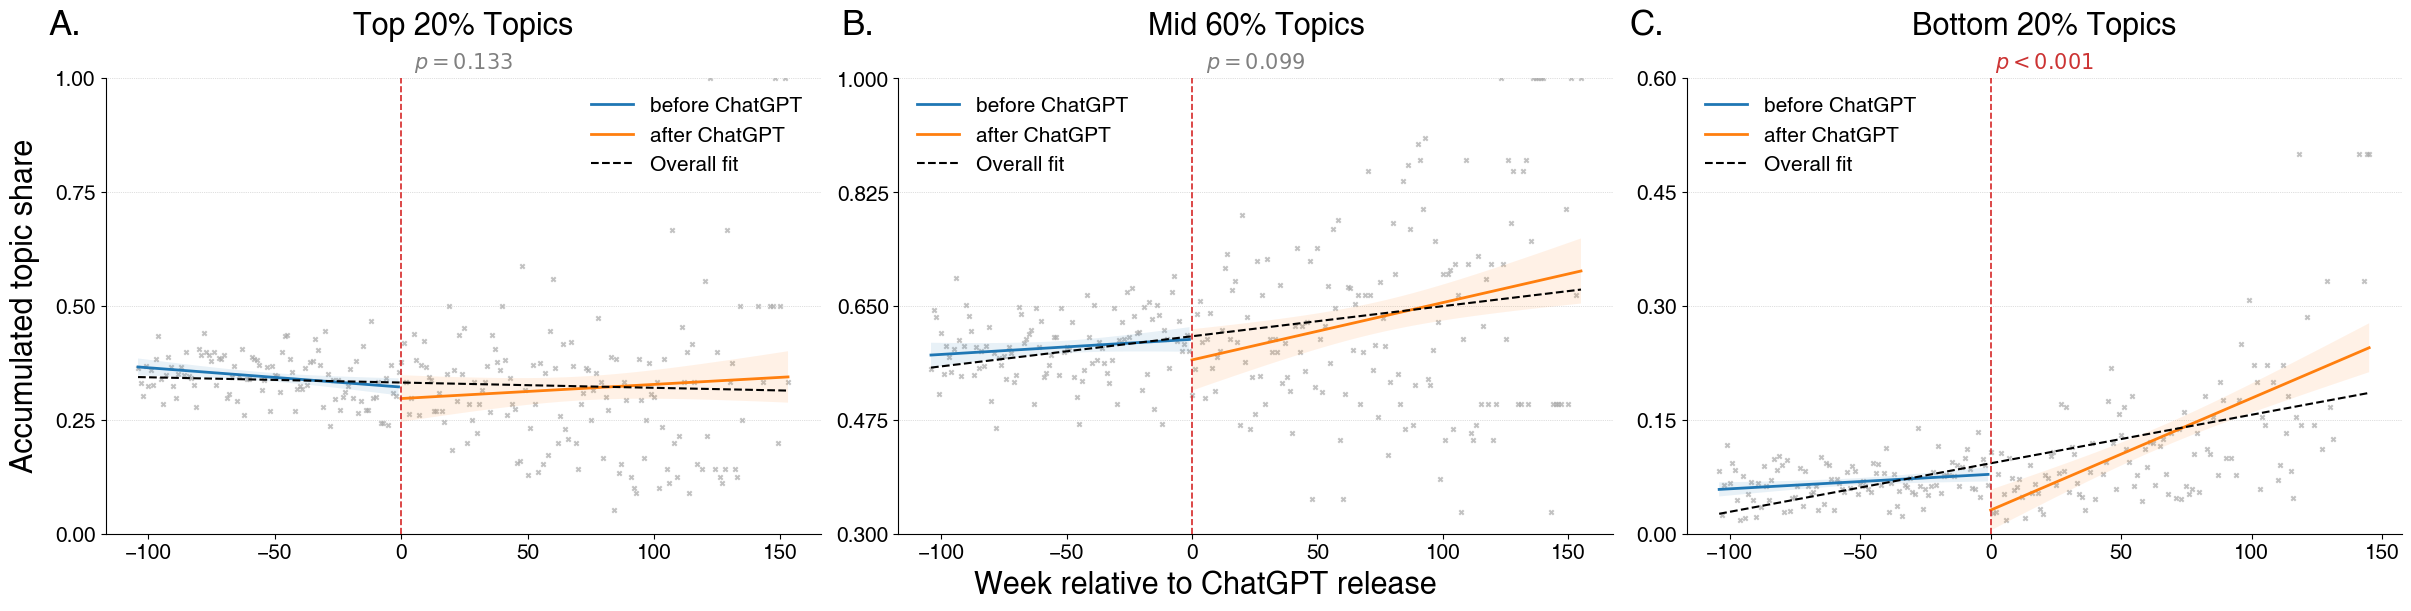

[Start....] drawing figures for julia language


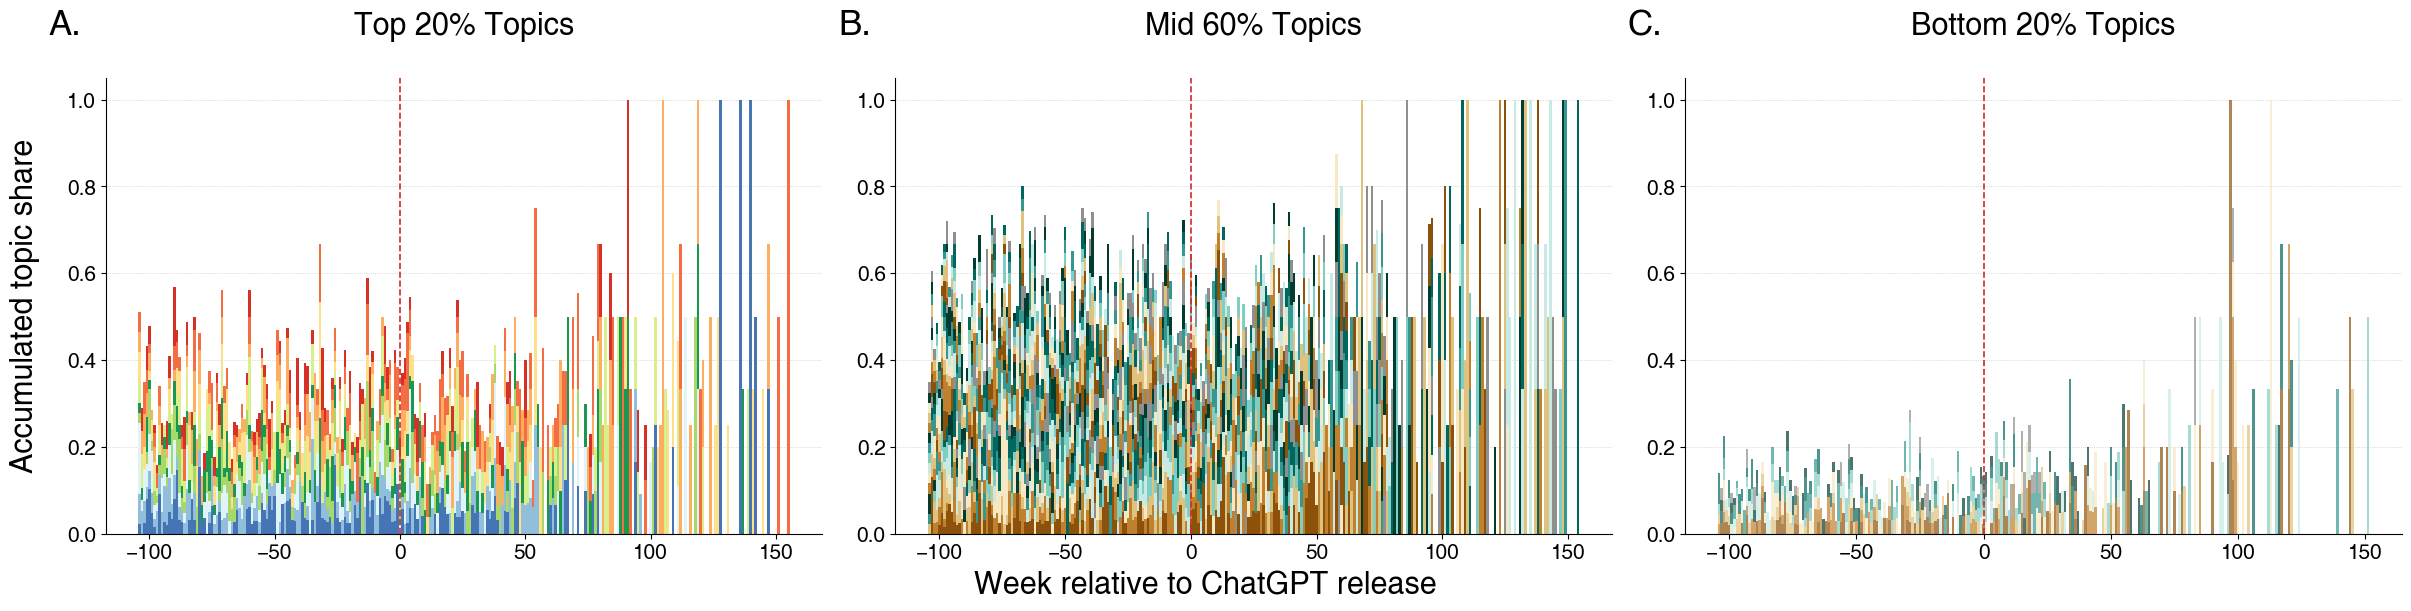

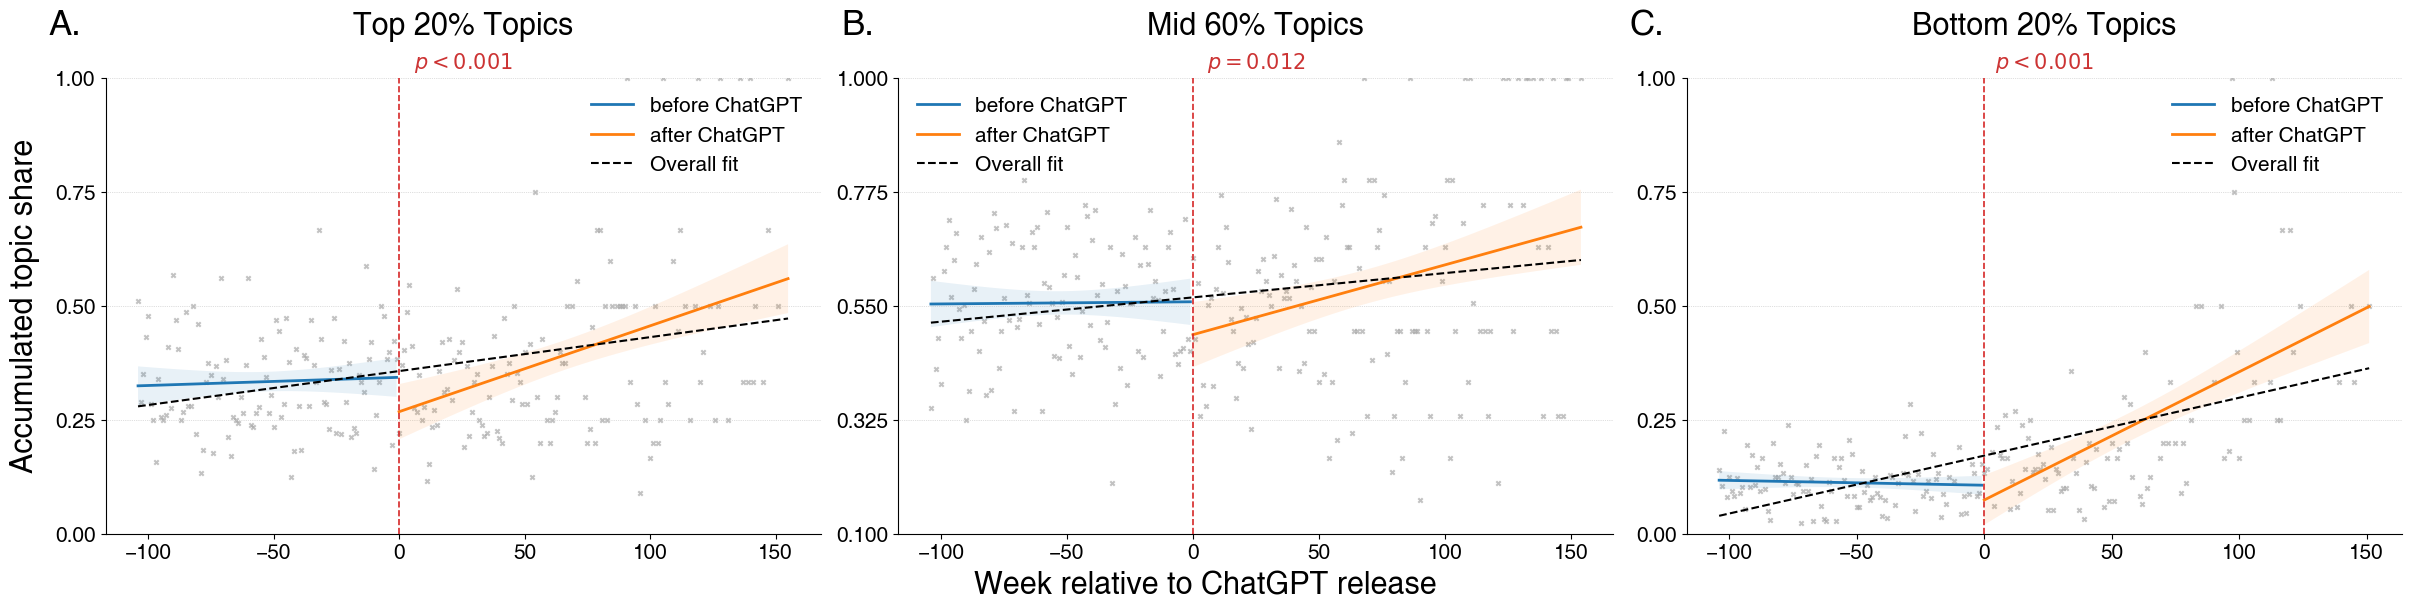

[Start....] drawing figures for matlab language


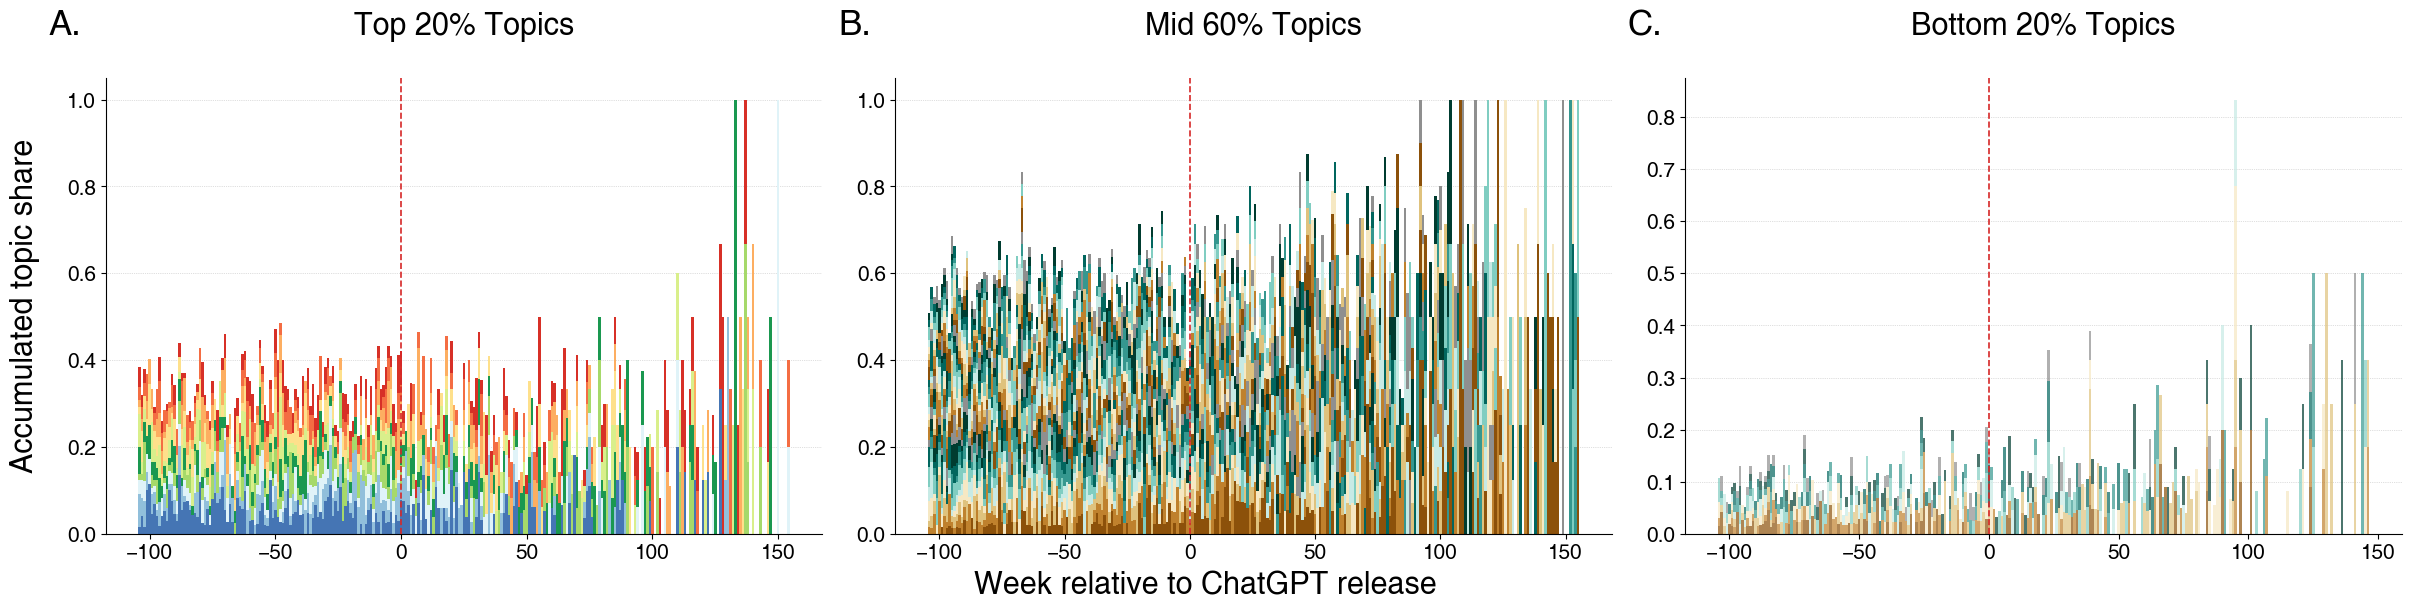

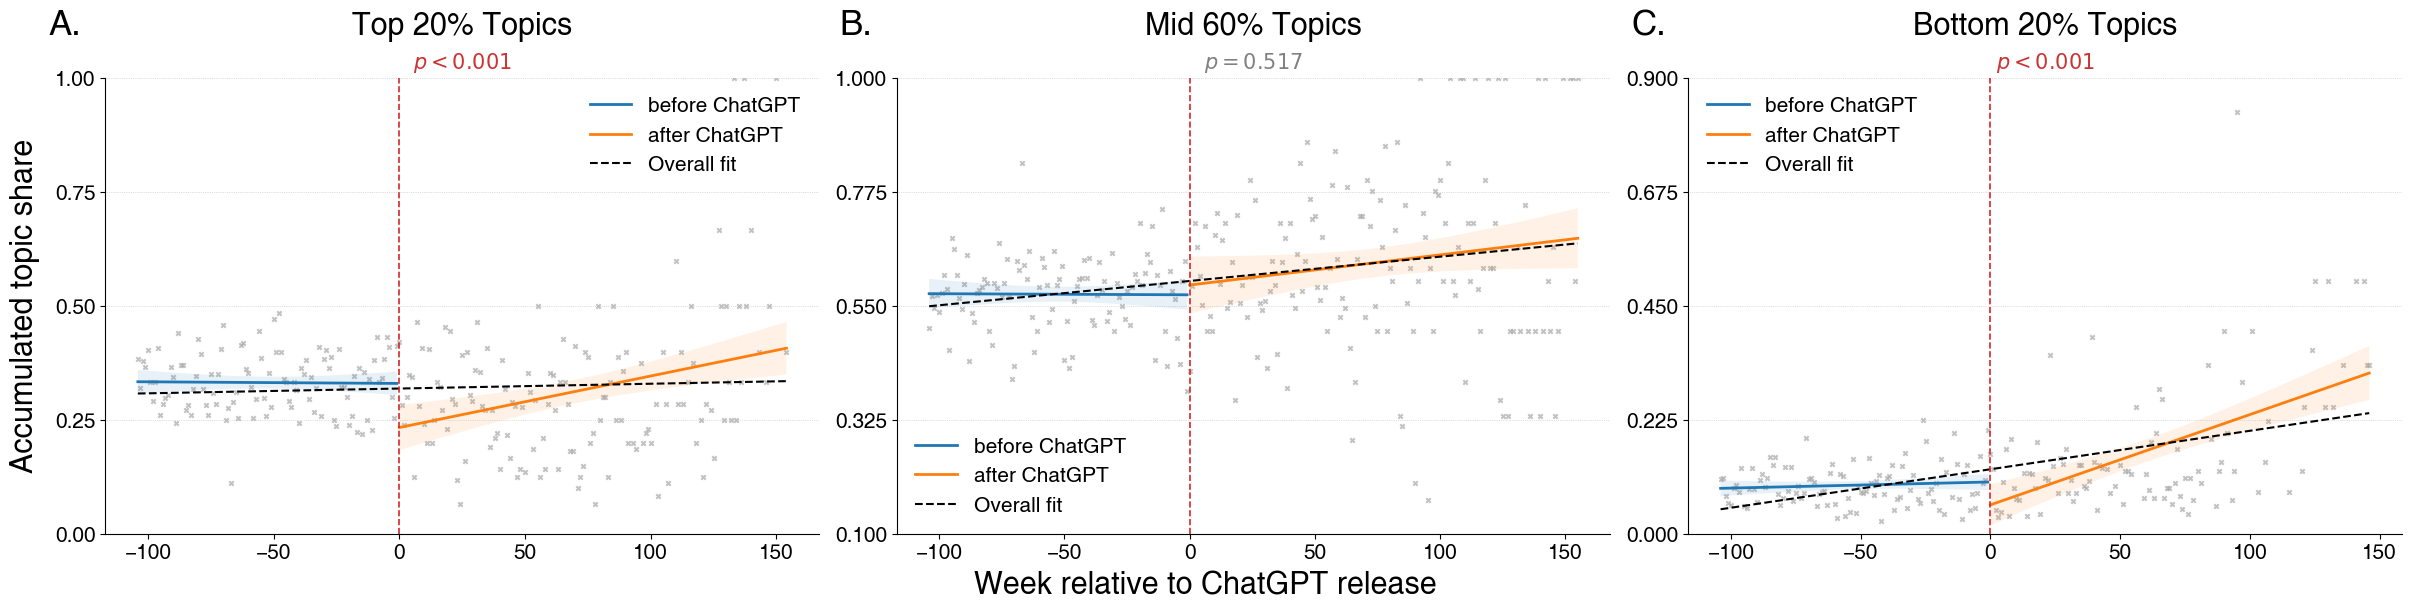

[Start....] drawing figures for groovy language


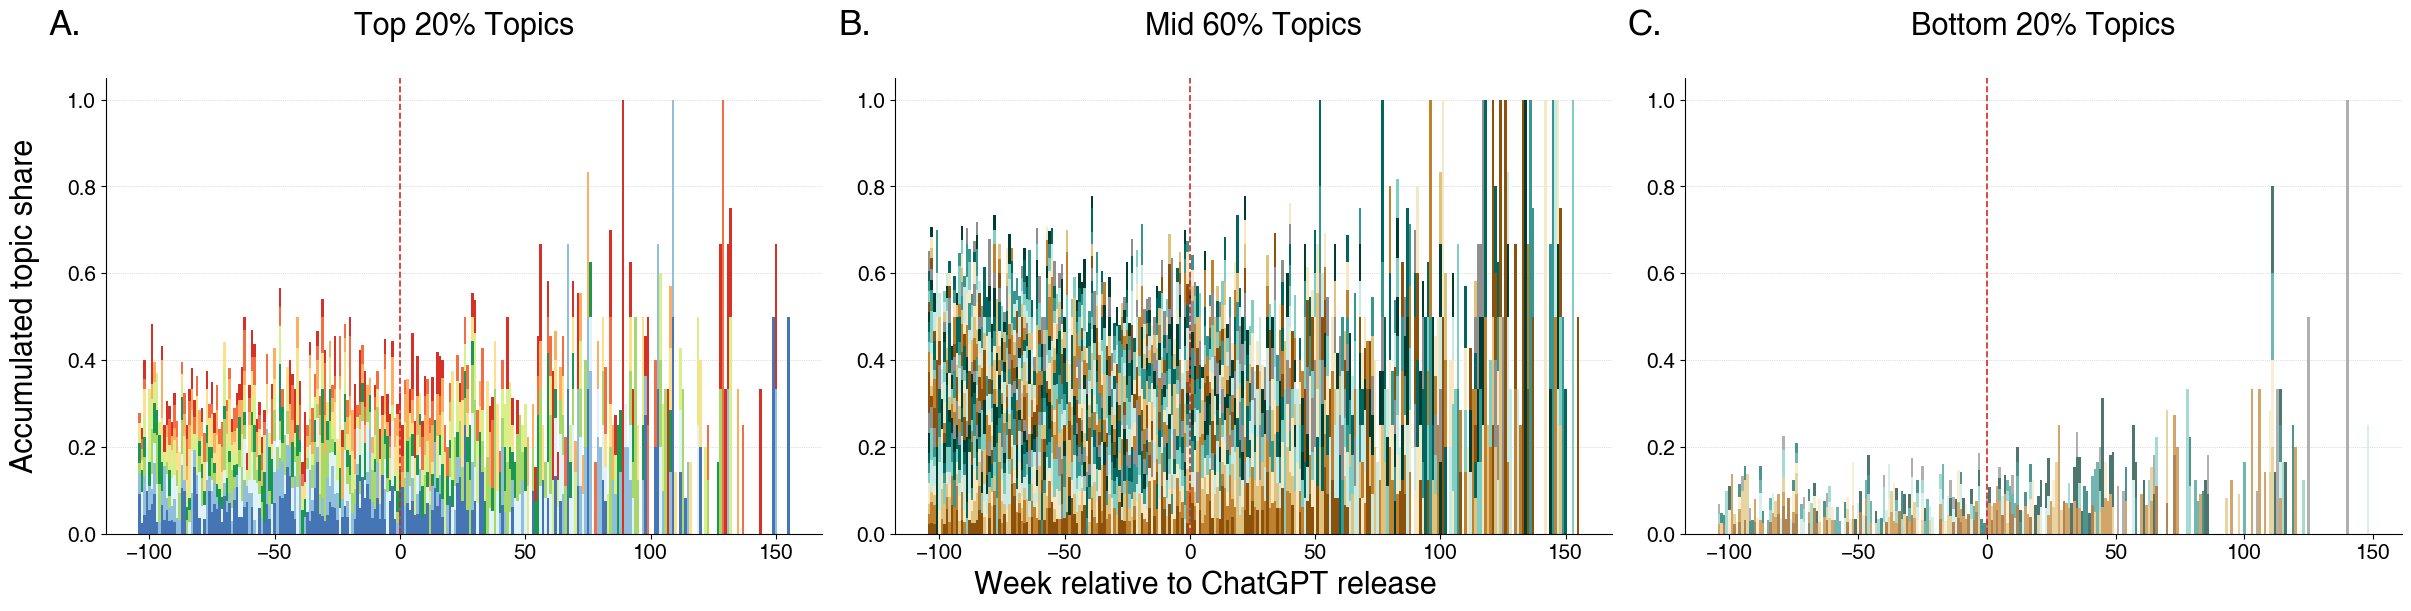

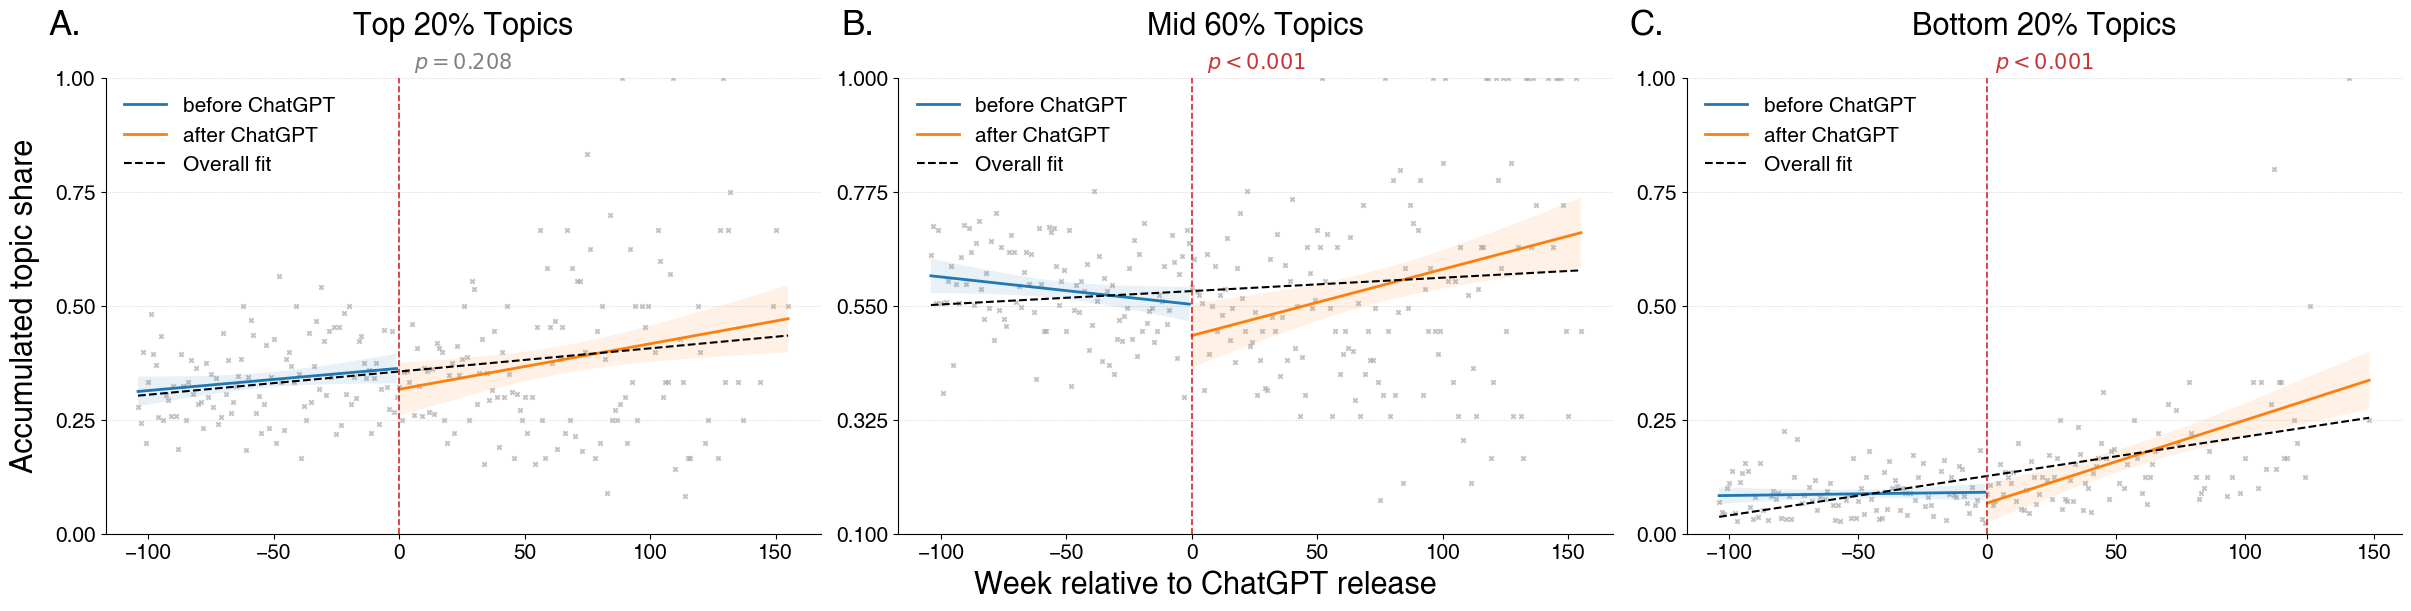

[Start....] drawing figures for objective-c language


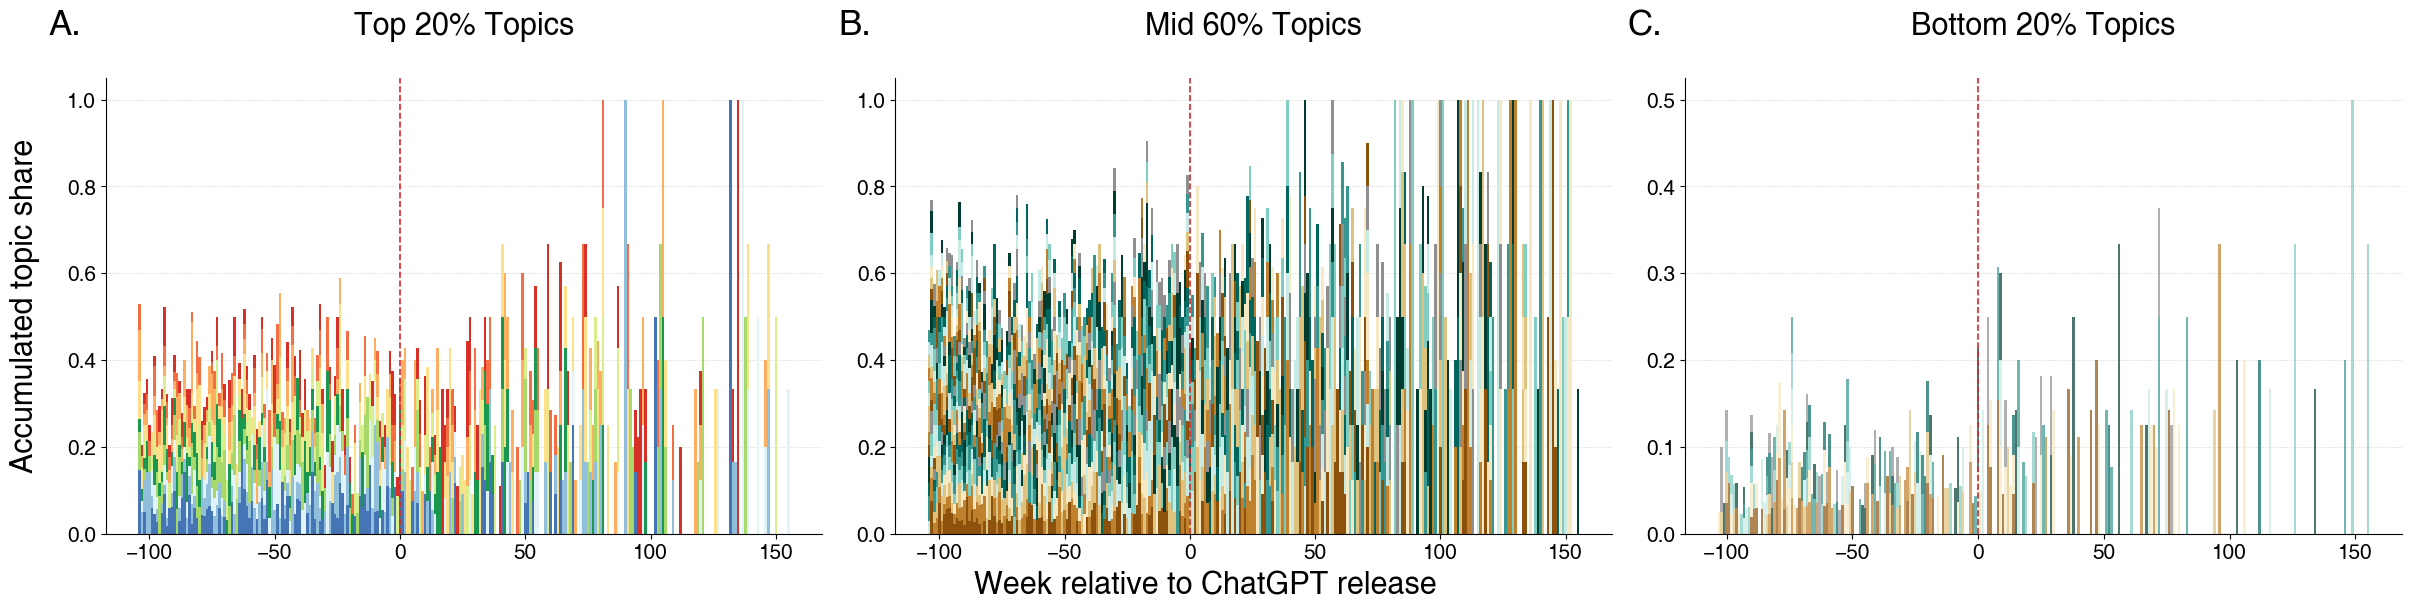

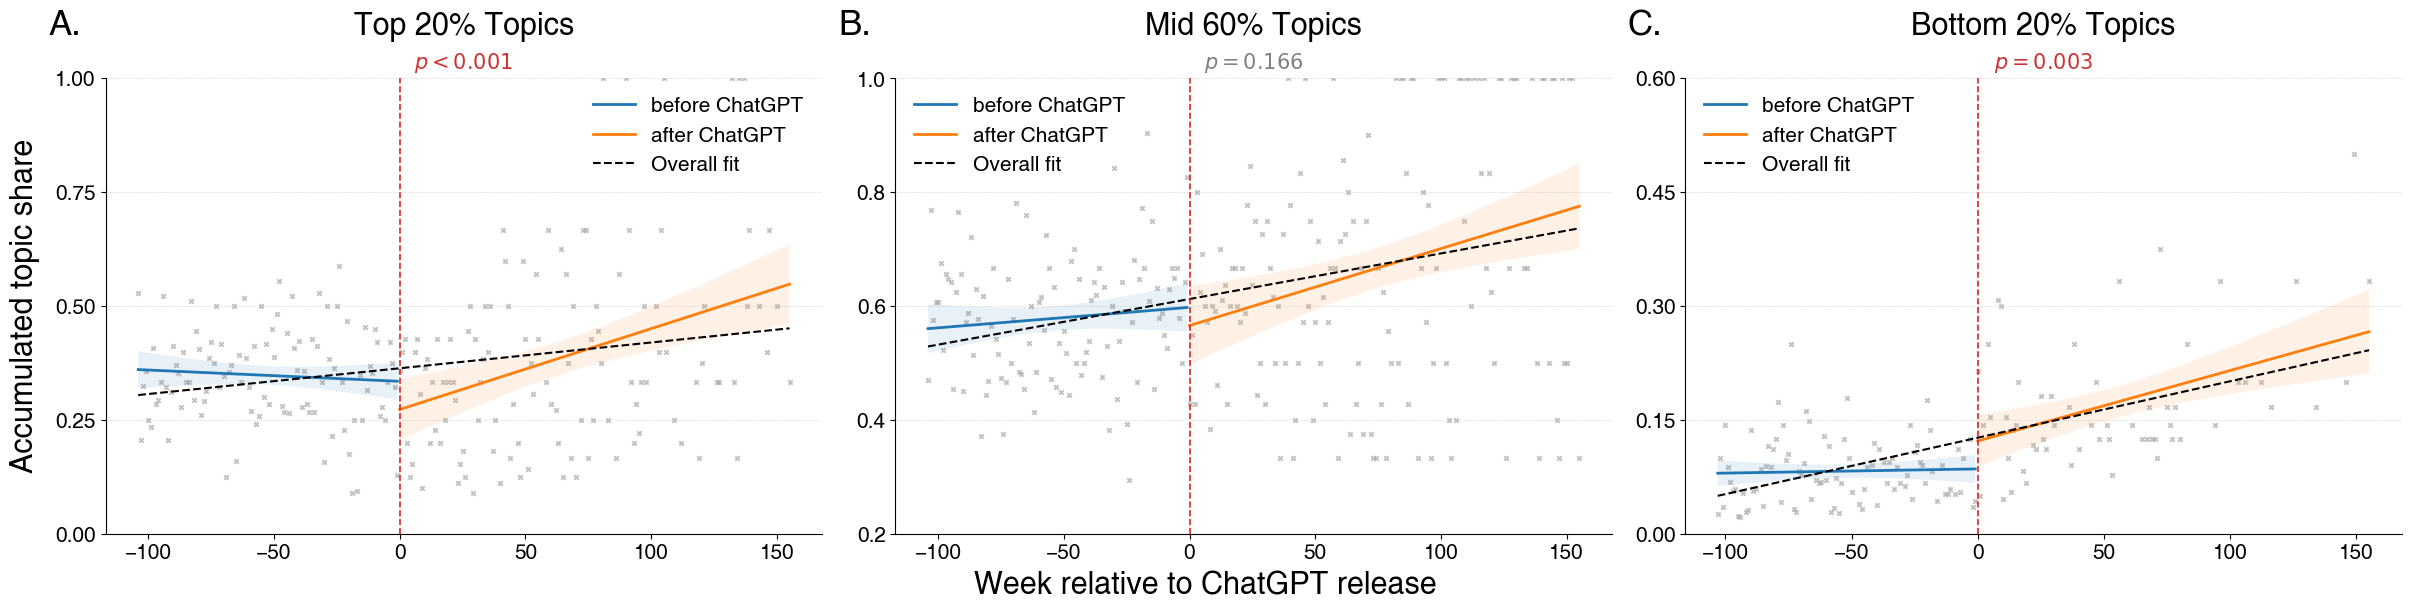

[Start....] drawing figures for vb.net language


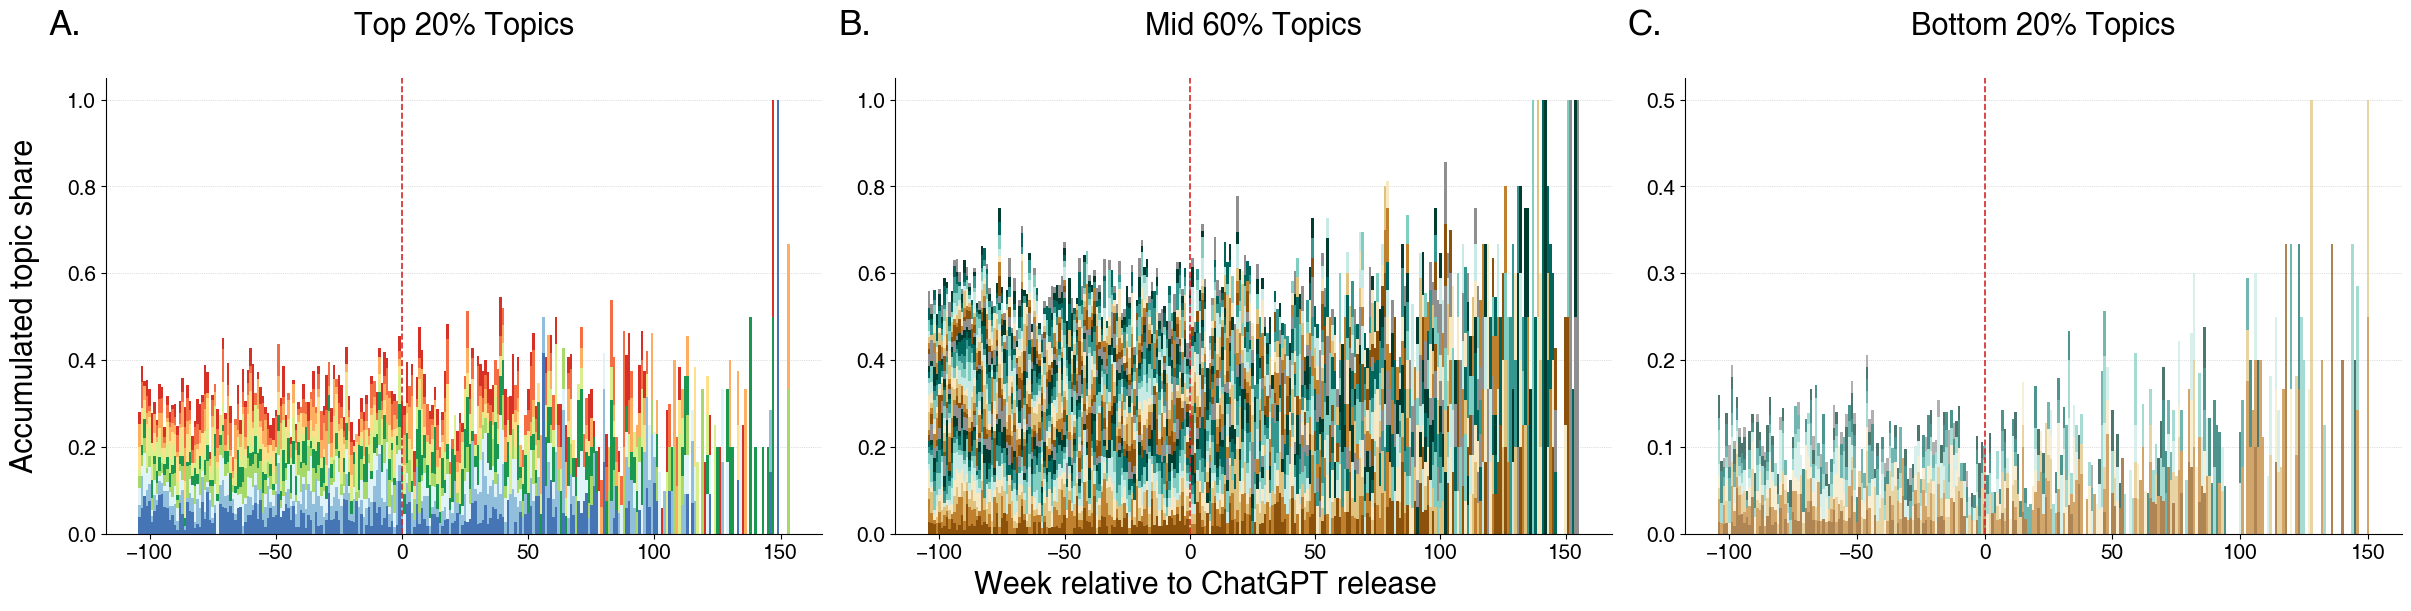

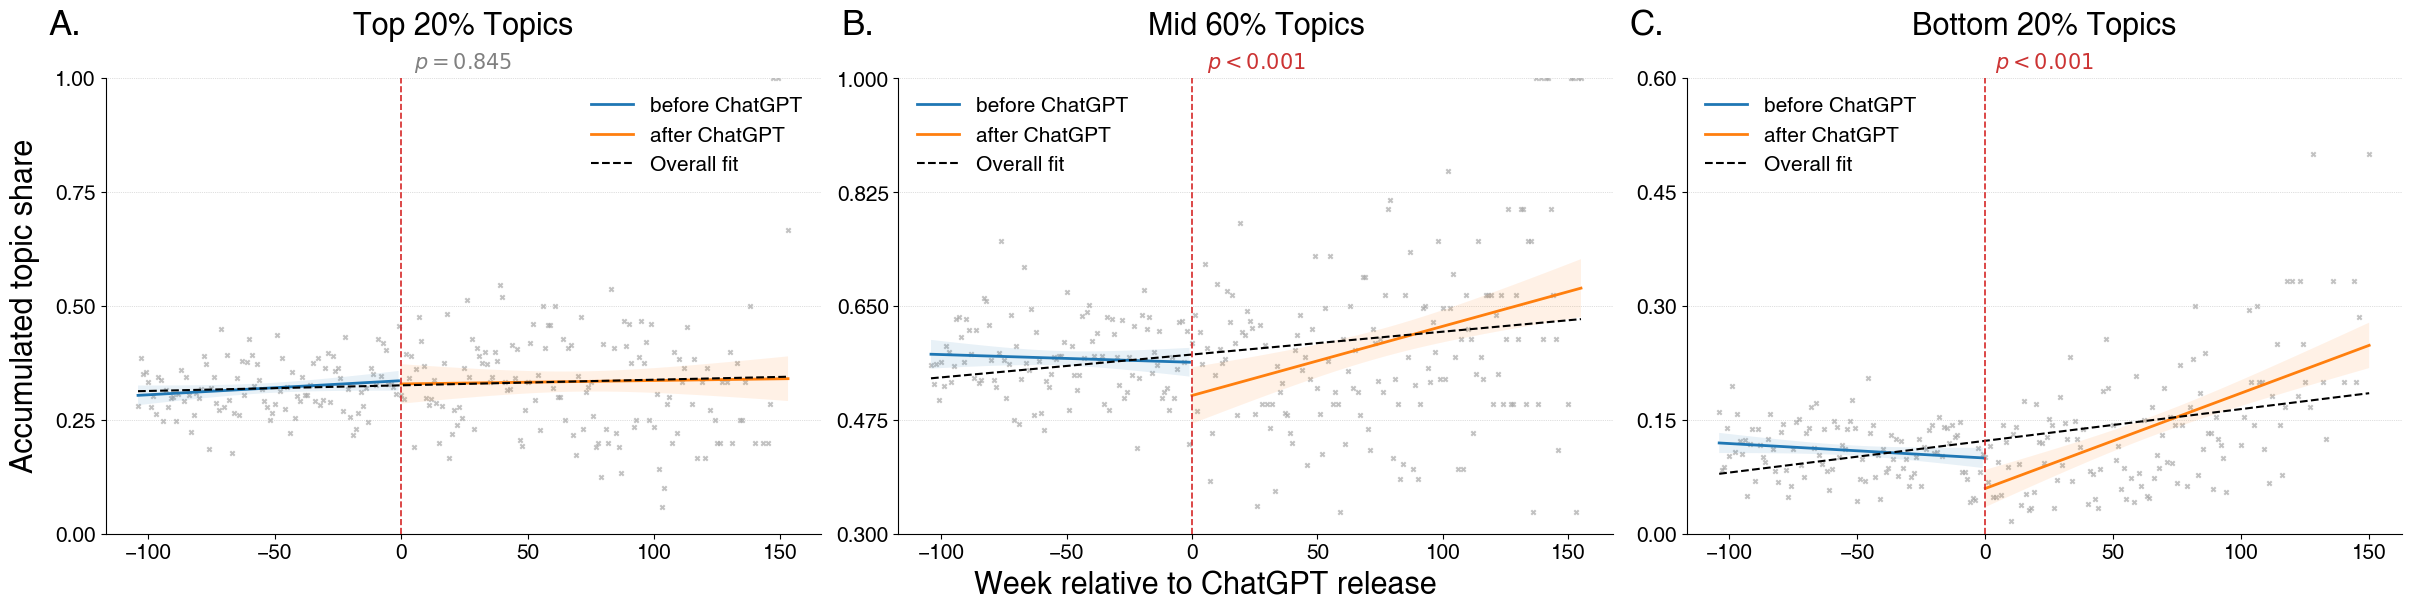

[Start....] drawing figures for assembly language


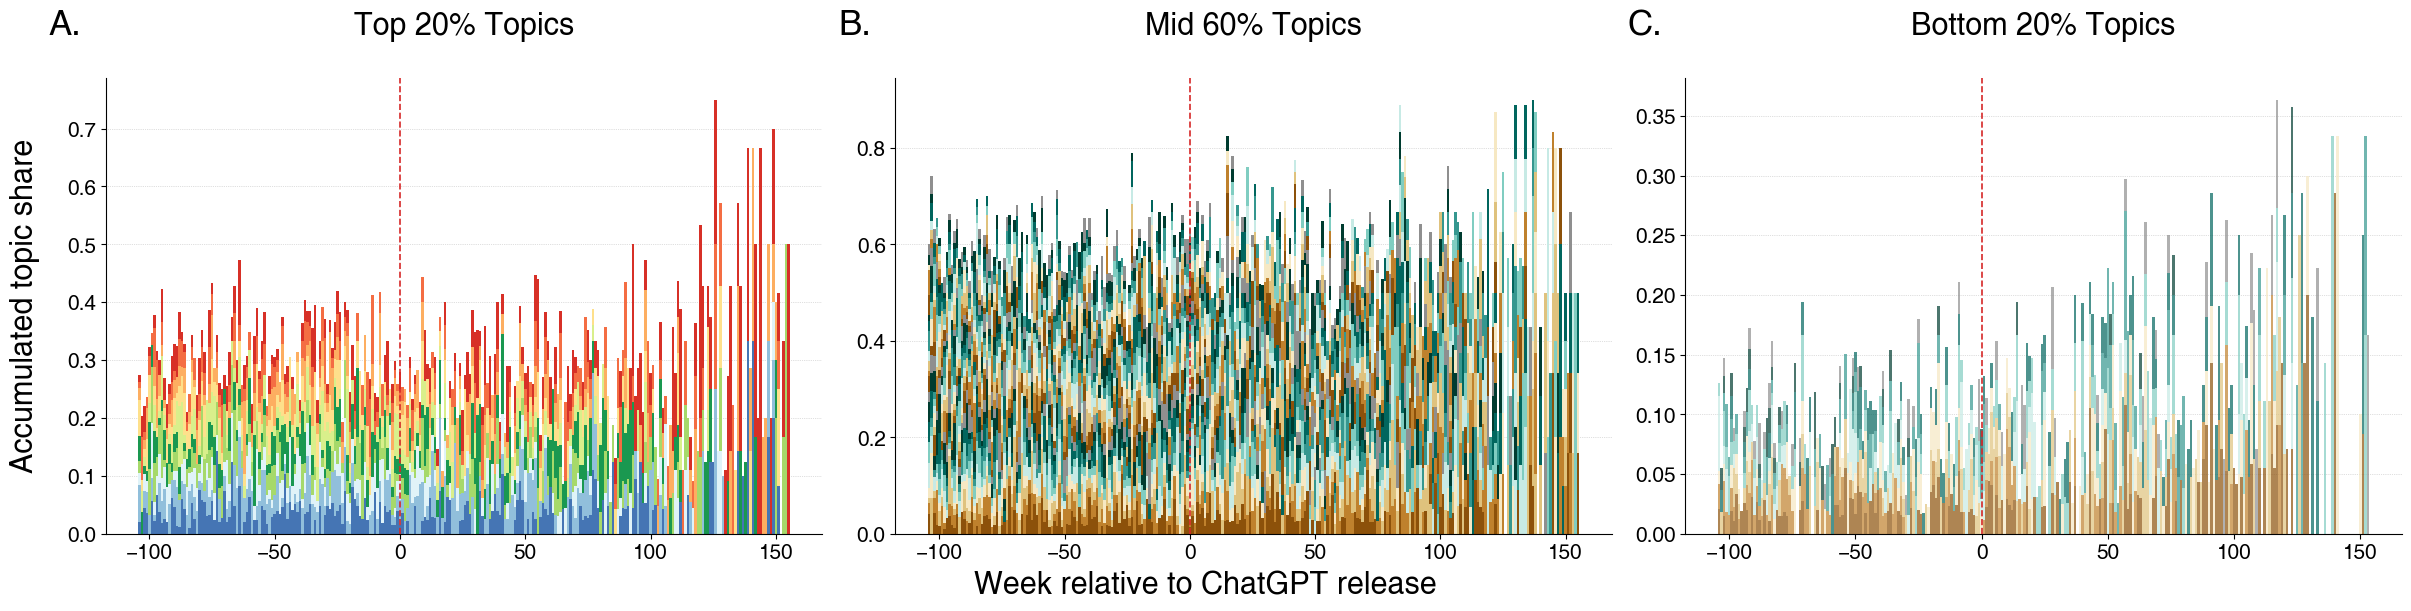

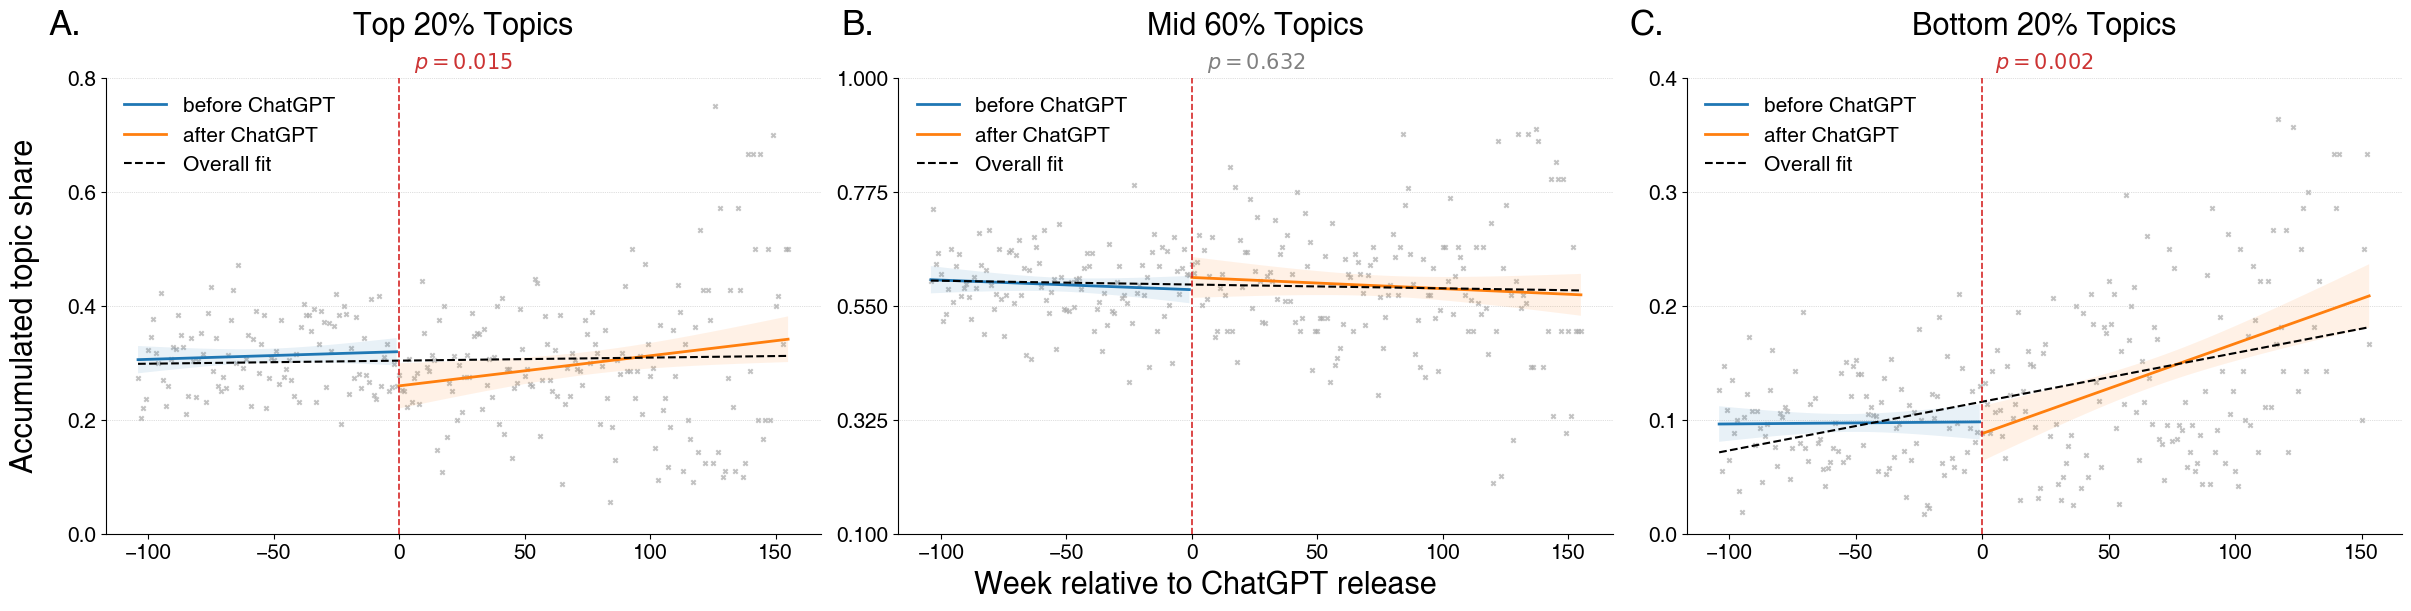

[Start....] drawing figures for haskell language


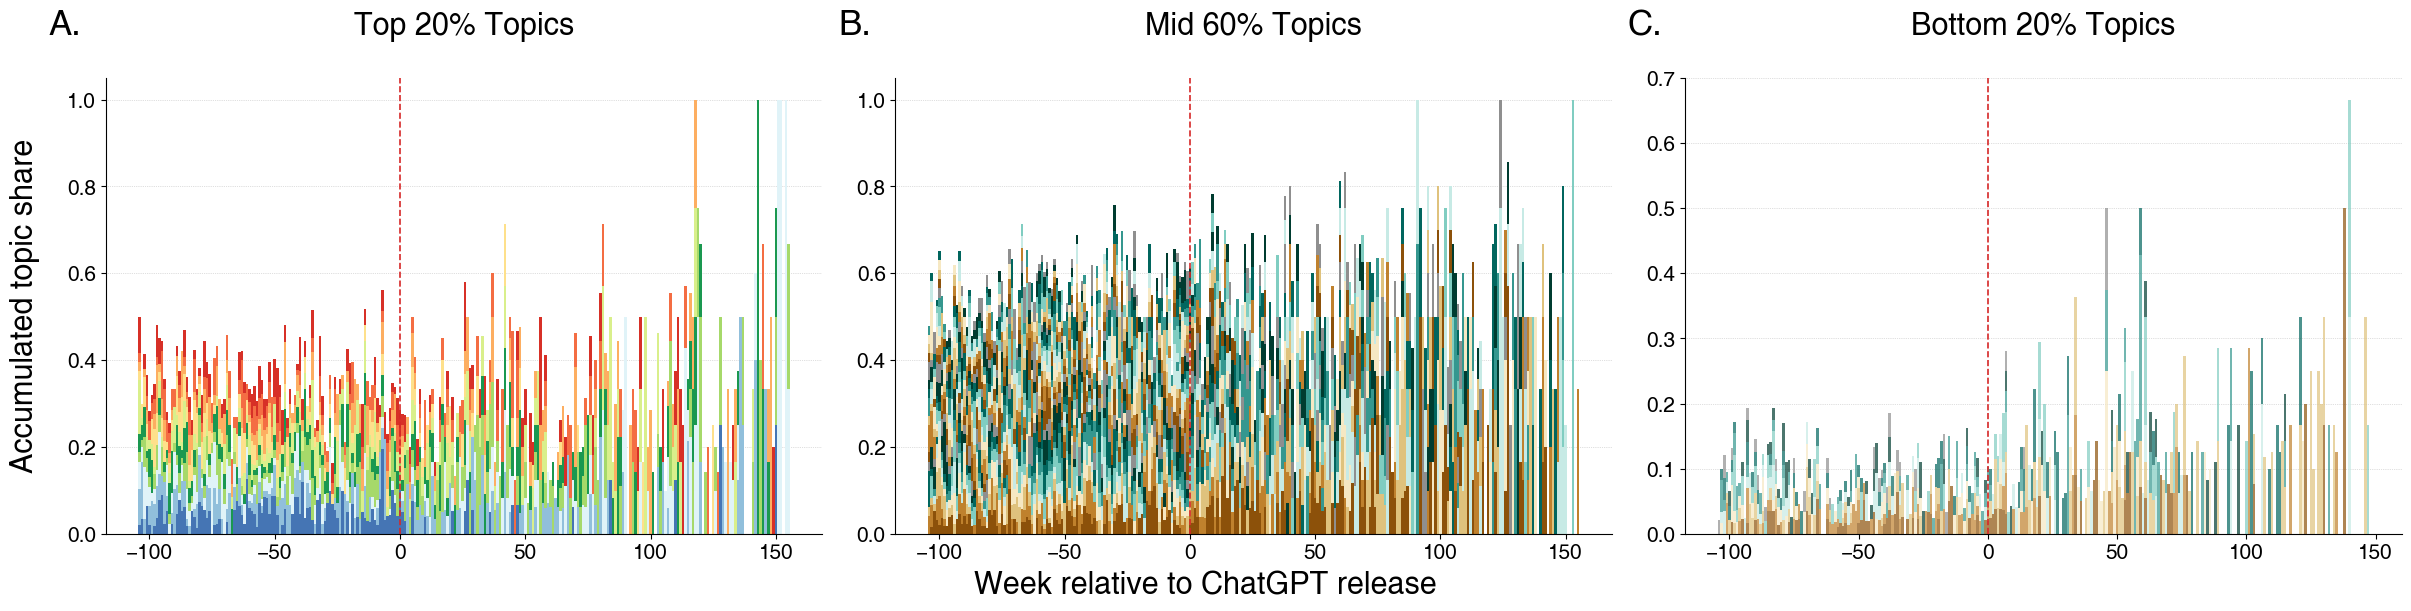

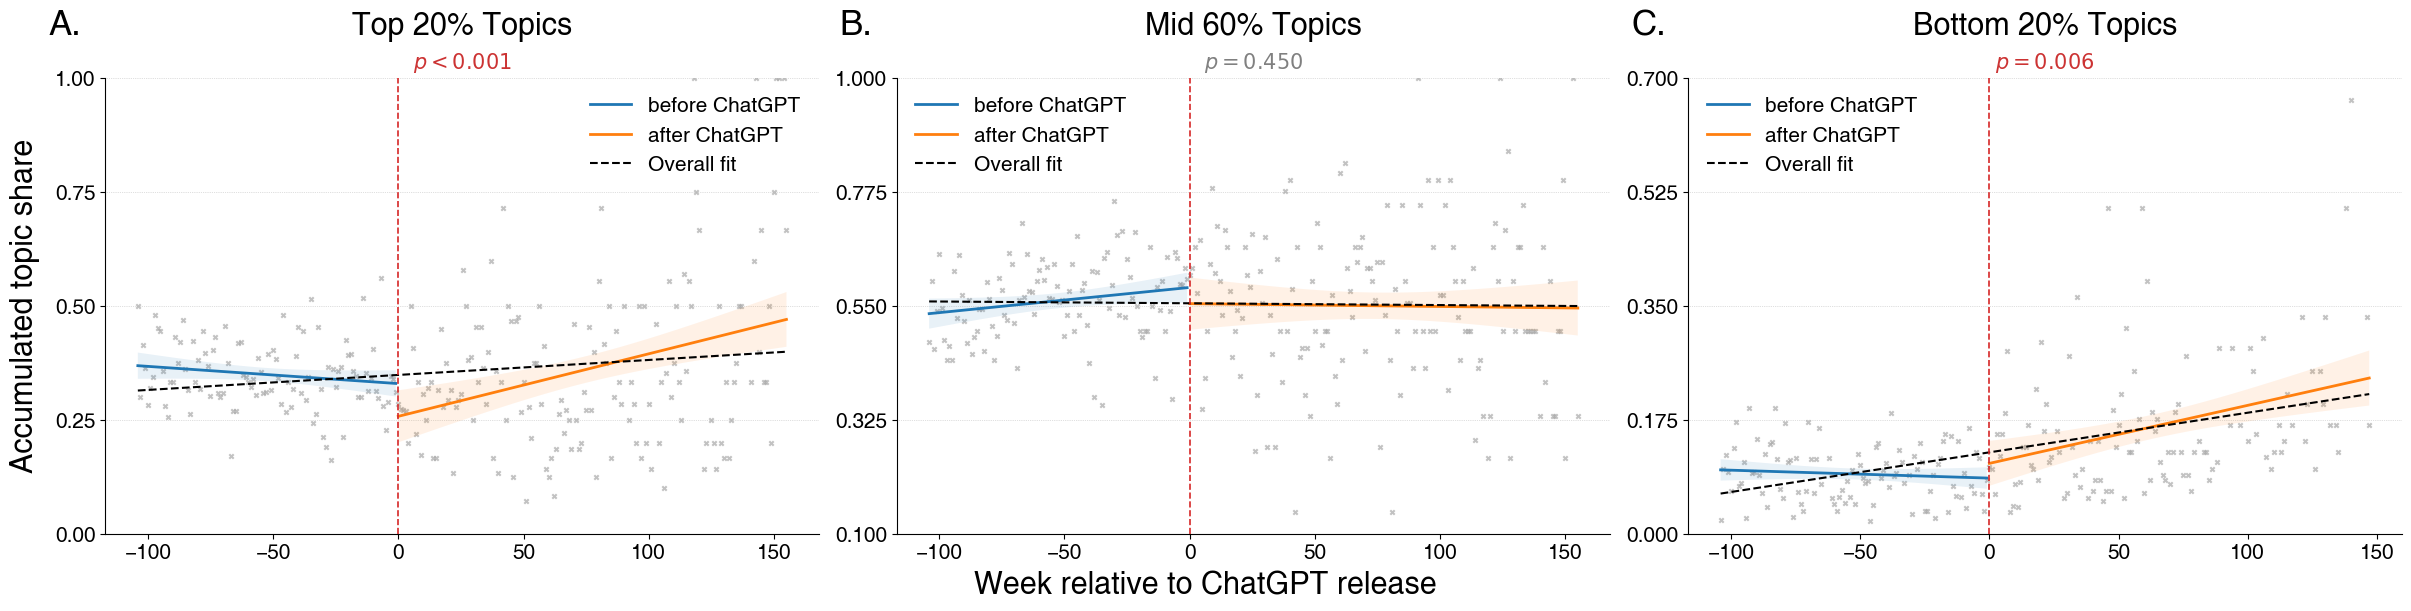

[Start....] drawing figures for delphi language


In [ ]:
idx = 0
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] drawing figures for {lang} language')
    visualization_target = f'run_id_{200+idx}'
    model_in_run = 'bert_based'
    viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    data_dir = f"{viz_dir}/data"
    option_dict = load_json(f"{viz_dir}/option.json")
    output_dir = './fig/'
    date_range = 'Weekly'
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = load_df(data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])
    df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed").dt.normalize()
    df['rel_week'] = ((df['creationdate'] - std_date).dt.days // 7)

    proportion_dict = dict()
    prop_df = proportion_calc_for_topic(df, 'rel_week', 'Topic')

    top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

    list_10 = {'Top 20% Topics' : top10list, 
                'Bottom 20% Topics' : bot10list, 
                'Mid 60% Topics': mid30list}


    proportion_dict = {     'Top 20% Topics'        : sort_distribution_by_list(prop_df, top10list),   
                            'Mid 60% Topics'        : sort_distribution_by_list(prop_df, mid30list),
                            'Bottom 20% Topics'     : sort_distribution_by_list(prop_df, bot10list),}

    draw_bar_plot_for_bertopic(idx, proportion_dict, list_10,option_dict, output_dir)
    draw_scatter_line_plot_for_bertopic(idx, proportion_dict, option_dict, output_dir)


    

In [ ]:
proportion_dict